<a href="https://colab.research.google.com/github/sophiakorneva/UltraSlowComponentModel/blob/main/rad51.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== RAD51 long table ===


,radiation,dose_Gy,time_h,RAD51_mean,RAD51_se,control_mean,control_se,delta_vs_ctrl,delta_se,fold_change_vs_ctrl,fold_change_se,cv
0,gamma,0.5,0.5,1.46,0.29,1.23,0.27,0.23,0.396232,1.186992,0.351397,0.198630
1,gamma,0.5,2.0,2.50,0.45,1.42,0.31,1.08,0.546443,1.760563,0.498147,0.180000
2,gamma,0.5,4.0,4.78,0.54,1.11,0.19,3.67,0.572451,4.306306,0.883181,0.112971
3,gamma,0.5,6.0,5.64,0.74,1.35,0.22,4.29,0.772010,4.177778,0.874063,0.131206
4,gamma,0.5,24.0,1.26,0.28,1.32,0.25,-0.06,0.375366,0.954545,0.278709,0.222222
5,gamma,1.0,0.5,1.54,0.38,1.23,0.27,0.31,0.466154,1.252033,0.413498,0.246753
6,gamma,1.0,2.0,3.70,0.58,1.42,0.31,2.28,0.657647,2.605634,0.700290,0.156757
7,gamma,1.0,4.0,6.73,0.67,1.11,0.19,5.62,0.696419,6.063063,1.200588,0.099554
8,gamma,1.0,6.0,7.65,0.58,1.35,0.22,6.30,0.620322,5.666667,1.018506,0.075817
9,gamma,1.0,24.0,1.32,0.33,1.32,0.25,0.00,0.414005,1.000000,0.313640,0.250000



=== RAD51 summary metrics ===


/tmp/ipykernel_40188/1494727758.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_delta = np.trapz(np.maximum(delta, 0), t)


,radiation,dose_Gy,peak_time_h_(2_6h_window),peak_RAD51_raw_(2_6h),peak_delta_vs_ctrl_(2_6h),residual_24h_delta,residual_24h_FC,persistence_index,AUC_delta_0.5_24h,n_timepoints_CV_gt_0.25
0,gamma,0.5,6.0,5.64,4.29,-0.06,0.954545,-0.013986,52.3025,0
1,gamma,1.0,6.0,7.65,6.30,0.00,1.000000,0.000000,78.4625,0
2,gamma,2.0,6.0,10.23,8.88,0.20,1.151515,0.022523,110.5550,2
3,proton_150MeV,0.5,6.0,6.17,4.82,0.72,1.545455,0.149378,66.7200,2
4,proton_150MeV,1.0,6.0,7.57,6.22,0.79,1.598485,0.127010,85.5425,1
5,proton_150MeV,2.0,6.0,10.57,9.22,1.39,2.053030,0.150759,125.5575,2
6,neutron_14MeV,0.5,6.0,7.01,5.66,4.01,4.037879,0.708481,105.4550,1
7,neutron_14MeV,1.0,6.0,8.51,7.16,4.70,4.560606,0.656425,133.0525,1
8,neutron_14MeV,2.0,6.0,11.07,9.72,5.76,5.363636,0.592593,173.0675,1


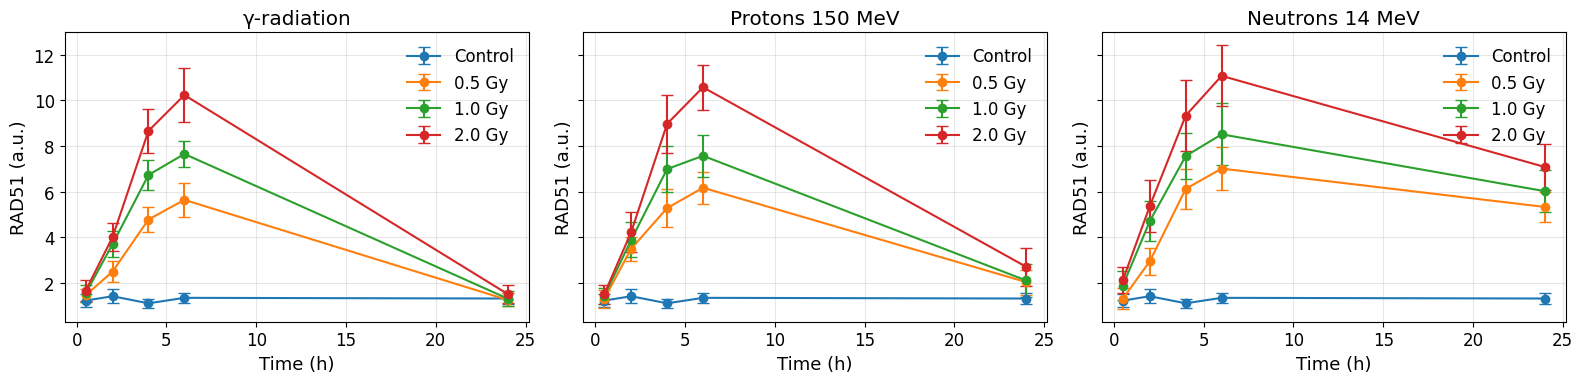

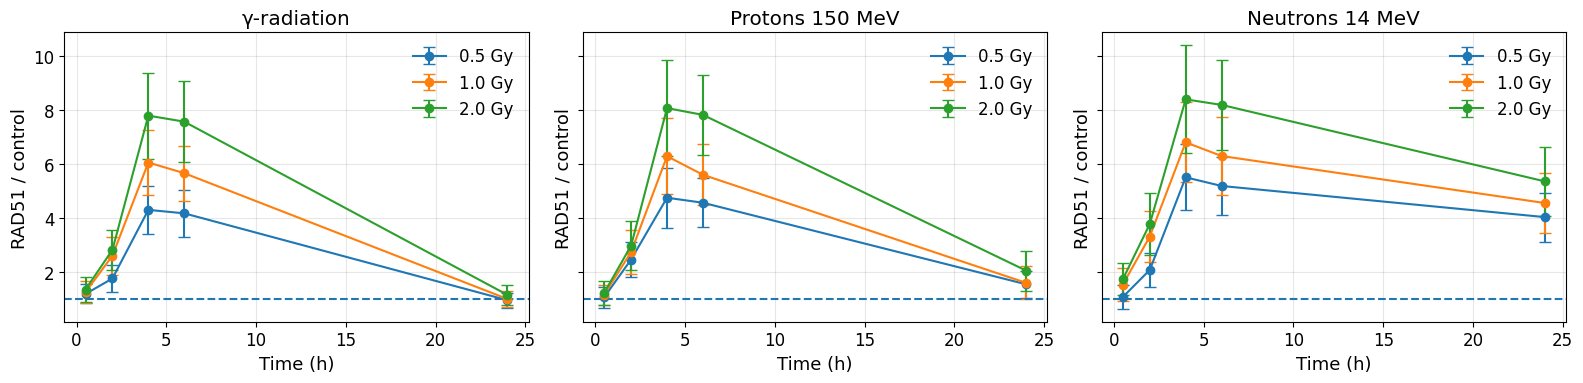

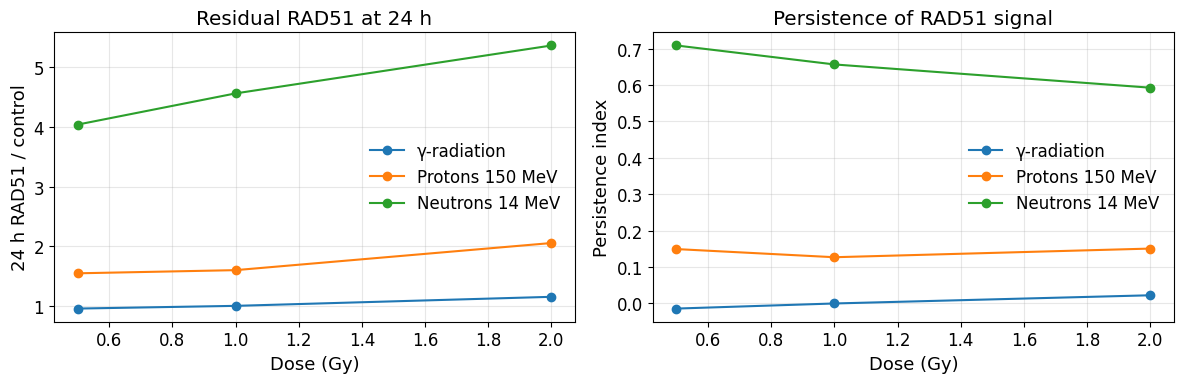

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================
# RAD51 data
# =========================
t = np.array([0.5, 2.0, 4.0, 6.0, 24.0], dtype=float)

ctrl_mean = np.array([1.23, 1.42, 1.11, 1.35, 1.32], dtype=float)
ctrl_se   = np.array([0.27, 0.31, 0.19, 0.22, 0.25], dtype=float)

RAD51 = {
    "gamma": {
        0.5: {"mean": np.array([1.46, 2.50, 4.78, 5.64, 1.26]), "se": np.array([0.29, 0.45, 0.54, 0.74, 0.28])},
        1.0: {"mean": np.array([1.54, 3.70, 6.73, 7.65, 1.32]), "se": np.array([0.38, 0.58, 0.67, 0.58, 0.33])},
        2.0: {"mean": np.array([1.66, 4.01, 8.66,10.23, 1.52]), "se": np.array([0.46, 0.60, 0.96, 1.17, 0.41])},
    },
    "neutron_14MeV": {
        0.5: {"mean": np.array([1.32, 2.95, 6.12, 7.01, 5.33]), "se": np.array([0.44, 0.59, 0.87, 0.93, 0.64])},
        1.0: {"mean": np.array([1.89, 4.71, 7.56, 8.51, 6.02]), "se": np.array([0.63, 0.87, 1.02, 1.36, 0.92])},
        2.0: {"mean": np.array([2.13, 5.37, 9.33,11.07, 7.08]), "se": np.array([0.57, 1.13, 1.54, 1.33, 1.01])},
    },
    "proton_150MeV": {
        0.5: {"mean": np.array([1.31, 3.50, 5.28, 6.17, 2.04]), "se": np.array([0.39, 0.52, 0.83, 0.71, 0.55])},
        1.0: {"mean": np.array([1.43, 3.89, 6.99, 7.57, 2.11]), "se": np.array([0.33, 0.77, 1.02, 0.91, 0.71])},
        2.0: {"mean": np.array([1.51, 4.23, 8.97,10.57, 2.71]), "se": np.array([0.42, 0.89, 1.26, 0.99, 0.83])},
    }
}

# =========================
# Helpers
# =========================
def ratio_with_se(a, sa, b, sb):
    """a/b with propagated SE"""
    ratio = a / b
    rel2 = (sa / a) ** 2 + (sb / b) ** 2
    se = ratio * np.sqrt(rel2)
    return ratio, se

def delta_with_se(a, sa, b, sb):
    """a-b with propagated SE"""
    return a - b, np.sqrt(sa**2 + sb**2)

# =========================
# Build long table
# =========================
rows = []

for rad, dose_dict in RAD51.items():
    for dose, vals in dose_dict.items():
        mean = vals["mean"]
        se = vals["se"]

        fc, fc_se = ratio_with_se(mean, se, ctrl_mean, ctrl_se)
        delta, delta_se = delta_with_se(mean, se, ctrl_mean, ctrl_se)
        cv = se / mean

        for i, ti in enumerate(t):
            rows.append({
                "radiation": rad,
                "dose_Gy": dose,
                "time_h": ti,
                "RAD51_mean": mean[i],
                "RAD51_se": se[i],
                "control_mean": ctrl_mean[i],
                "control_se": ctrl_se[i],
                "delta_vs_ctrl": delta[i],
                "delta_se": delta_se[i],
                "fold_change_vs_ctrl": fc[i],
                "fold_change_se": fc_se[i],
                "cv": cv[i],
            })

df_rad51 = pd.DataFrame(rows)

print("=== RAD51 long table ===")
display(df_rad51)

# =========================
# Summary metrics
# =========================
summary_rows = []

# use 2-6 h window as "late-early HR recruitment window"
mask_peak = np.isin(t, [2.0, 4.0, 6.0])

for rad, dose_dict in RAD51.items():
    for dose, vals in dose_dict.items():
        mean = vals["mean"]
        se = vals["se"]

        delta, delta_se = delta_with_se(mean, se, ctrl_mean, ctrl_se)
        fc, fc_se = ratio_with_se(mean, se, ctrl_mean, ctrl_se)

        peak_idx_local = np.argmax(delta[mask_peak])
        peak_times = t[mask_peak]
        peak_deltas = delta[mask_peak]
        peak_raw = mean[mask_peak]

        peak_time = peak_times[peak_idx_local]
        peak_delta = peak_deltas[peak_idx_local]
        peak_raw_val = peak_raw[peak_idx_local]

        residual_24h_delta = delta[-1]
        residual_24h_fc = fc[-1]

        persistence_index = np.nan
        if peak_delta > 0:
            persistence_index = residual_24h_delta / peak_delta

        auc_delta = np.trapz(np.maximum(delta, 0), t)

        # optional rough QC flag: high uncertainty
        high_cv_points = int(np.sum((se / mean) > 0.25))

        summary_rows.append({
            "radiation": rad,
            "dose_Gy": dose,
            "peak_time_h_(2_6h_window)": peak_time,
            "peak_RAD51_raw_(2_6h)": peak_raw_val,
            "peak_delta_vs_ctrl_(2_6h)": peak_delta,
            "residual_24h_delta": residual_24h_delta,
            "residual_24h_FC": residual_24h_fc,
            "persistence_index": persistence_index,
            "AUC_delta_0.5_24h": auc_delta,
            "n_timepoints_CV_gt_0.25": high_cv_points,
        })

df_summary = pd.DataFrame(summary_rows)

# nicer ordering
rad_order = {"gamma": 0, "proton_150MeV": 1, "neutron_14MeV": 2}
df_summary["_order"] = df_summary["radiation"].map(rad_order)
df_summary = df_summary.sort_values(["_order", "dose_Gy"]).drop(columns="_order").reset_index(drop=True)

print("\n=== RAD51 summary metrics ===")
display(df_summary)

# =========================
# Plot 1: raw RAD51
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

rad_titles = {
    "gamma": "γ-radiation",
    "proton_150MeV": "Protons 150 MeV",
    "neutron_14MeV": "Neutrons 14 MeV"
}

for ax, rad in zip(axes, ["gamma", "proton_150MeV", "neutron_14MeV"]):
    ax.errorbar(t, ctrl_mean, yerr=ctrl_se, fmt="o-", capsize=4, label="Control")
    for dose in sorted(RAD51[rad].keys()):
        vals = RAD51[rad][dose]
        ax.errorbar(t, vals["mean"], yerr=vals["se"], fmt="o-", capsize=4, label=f"{dose} Gy")
    ax.set_title(rad_titles[rad])
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("RAD51 (a.u.)")
    ax.legend()

plt.tight_layout()
plt.show()

# =========================
# Plot 2: fold change vs control
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

for ax, rad in zip(axes, ["gamma", "proton_150MeV", "neutron_14MeV"]):
    for dose in sorted(RAD51[rad].keys()):
        sub = df_rad51[(df_rad51["radiation"] == rad) & (df_rad51["dose_Gy"] == dose)]
        ax.errorbar(
            sub["time_h"], sub["fold_change_vs_ctrl"], yerr=sub["fold_change_se"],
            fmt="o-", capsize=4, label=f"{dose} Gy"
        )
    ax.axhline(1.0, linestyle="--")
    ax.set_title(rad_titles[rad])
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("RAD51 / control")
    ax.legend()

plt.tight_layout()
plt.show()

# =========================
# Plot 3: 24 h residual FC and persistence index
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for rad in ["gamma", "proton_150MeV", "neutron_14MeV"]:
    sub = df_summary[df_summary["radiation"] == rad].sort_values("dose_Gy")
    axes[0].plot(sub["dose_Gy"], sub["residual_24h_FC"], marker="o", label=rad_titles[rad])
    axes[1].plot(sub["dose_Gy"], sub["persistence_index"], marker="o", label=rad_titles[rad])

axes[0].set_xlabel("Dose (Gy)")
axes[0].set_ylabel("24 h RAD51 / control")
axes[0].set_title("Residual RAD51 at 24 h")

axes[1].set_xlabel("Dose (Gy)")
axes[1].set_ylabel("Persistence index")
axes[1].set_title("Persistence of RAD51 signal")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Model feature table ===


,radiation,dose_Gy,alpha,pi,slow_pool,Du0_fraction,Dc0_fraction,Du0_abs,Dc0_abs
0,gamma,0.25,0.134241,0.056817,0.865759,0.049190,0.816569,0.012297,0.204142
1,gamma,0.50,0.231623,0.024713,0.768377,0.018989,0.749388,0.009494,0.374694
2,gamma,1.00,0.190034,0.045250,0.809966,0.036651,0.773315,0.036651,0.773315
3,gamma,2.00,0.385335,0.063004,0.614665,0.038726,0.575939,0.077453,1.151877
4,neutron_14MeV,0.25,0.578154,0.312767,0.421846,0.131940,0.289906,0.032985,0.072477
5,neutron_14MeV,0.50,0.588580,0.288091,0.411420,0.118526,0.292894,0.059263,0.146447
6,neutron_14MeV,1.00,0.710574,0.322786,0.289426,0.093423,0.196003,0.093423,0.196003
7,neutron_14MeV,2.00,0.804320,0.448824,0.195680,0.087826,0.107854,0.175652,0.215708
8,proton_150MeV,0.25,0.338224,0.161725,0.661776,0.107026,0.554750,0.026756,0.138688
9,proton_150MeV,0.50,0.687007,0.329032,0.312993,0.102985,0.210008,0.051492,0.105004


=== Merged RAD51 + model table ===


,radiation,dose_Gy,peak_time_h_(2_6h_window),peak_RAD51_raw_(2_6h),peak_delta_vs_ctrl_(2_6h),residual_24h_delta,residual_24h_FC,persistence_index,AUC_delta_0.5_24h,n_timepoints_CV_gt_0.25,alpha,pi,slow_pool,Du0_fraction,Dc0_fraction,Du0_abs,Dc0_abs
0,gamma,0.5,6.0,5.64,4.29,-0.06,0.954545,-0.013986,52.3025,0,0.231623,0.024713,0.768377,0.018989,0.749388,0.009494,0.374694
1,gamma,1.0,6.0,7.65,6.30,0.00,1.000000,0.000000,78.4625,0,0.190034,0.045250,0.809966,0.036651,0.773315,0.036651,0.773315
2,gamma,2.0,6.0,10.23,8.88,0.20,1.151515,0.022523,110.5550,2,0.385335,0.063004,0.614665,0.038726,0.575939,0.077453,1.151877
3,proton_150MeV,0.5,6.0,6.17,4.82,0.72,1.545455,0.149378,66.7200,2,0.687007,0.329032,0.312993,0.102985,0.210008,0.051492,0.105004
4,proton_150MeV,1.0,6.0,7.57,6.22,0.79,1.598485,0.127010,85.5425,1,0.319425,0.091171,0.680575,0.062049,0.618526,0.062049,0.618526
5,proton_150MeV,2.0,6.0,10.57,9.22,1.39,2.053030,0.150759,125.5575,2,0.552002,0.127730,0.447998,0.057223,0.390775,0.114446,0.781550
6,neutron_14MeV,0.5,6.0,7.01,5.66,4.01,4.037879,0.708481,105.4550,1,0.588580,0.288091,0.411420,0.118526,0.292894,0.059263,0.146447
7,neutron_14MeV,1.0,6.0,8.51,7.16,4.70,4.560606,0.656425,133.0525,1,0.710574,0.322786,0.289426,0.093423,0.196003,0.093423,0.196003
8,neutron_14MeV,2.0,6.0,11.07,9.72,5.76,5.363636,0.592593,173.0675,1,0.804320,0.448824,0.195680,0.087826,0.107854,0.175652,0.215708


=== Spearman correlations ===


,RAD51_metric,model_feature,spearman_rho,p_value,n
0,AUC_delta_0.5_24h,Du0_abs,0.950000,0.000088,9
1,AUC_delta_0.5_24h,alpha,0.666667,0.049867,9
2,AUC_delta_0.5_24h,pi,0.566667,0.111633,9
3,AUC_delta_0.5_24h,Du0_fraction,0.316667,0.406397,9
4,AUC_delta_0.5_24h,Dc0_abs,0.116667,0.765008,9
5,AUC_delta_0.5_24h,Dc0_fraction,-0.666667,0.049867,9
6,peak_delta_vs_ctrl_(2_6h),Du0_abs,0.883333,0.001591,9
7,peak_delta_vs_ctrl_(2_6h),Dc0_abs,0.466667,0.205386,9
8,peak_delta_vs_ctrl_(2_6h),alpha,0.383333,0.308495,9
9,peak_delta_vs_ctrl_(2_6h),pi,0.333333,0.380713,9


=== Descriptive linear fits ===


,RAD51_metric,model_feature,slope,intercept,r_value,r_squared,p_value,n
0,AUC_delta_0.5_24h,Du0_abs,736.424402,47.778175,0.954078,0.910265,0.000065,9
1,AUC_delta_0.5_24h,alpha,115.509098,46.057377,0.687762,0.473017,0.040597,9
2,AUC_delta_0.5_24h,Dc0_fraction,-98.594236,146.298013,-0.661931,0.438152,0.052118,9
3,AUC_delta_0.5_24h,pi,149.348506,74.528760,0.618233,0.382212,0.075968,9
4,AUC_delta_0.5_24h,Du0_fraction,423.542195,74.404968,0.384429,0.147786,0.306997,9
5,AUC_delta_0.5_24h,Dc0_abs,-6.300123,106.467025,-0.061380,0.003767,0.875350,9
6,peak_delta_vs_ctrl_(2_6h),Du0_abs,34.975104,4.276627,0.862903,0.744601,0.002740,9
7,peak_delta_vs_ctrl_(2_6h),Dc0_abs,2.270100,5.818363,0.421180,0.177392,0.258911,9
8,peak_delta_vs_ctrl_(2_6h),alpha,3.325232,5.267764,0.377043,0.142162,0.317168,9
9,peak_delta_vs_ctrl_(2_6h),Dc0_fraction,-2.605167,8.052051,-0.333076,0.110940,0.381104,9


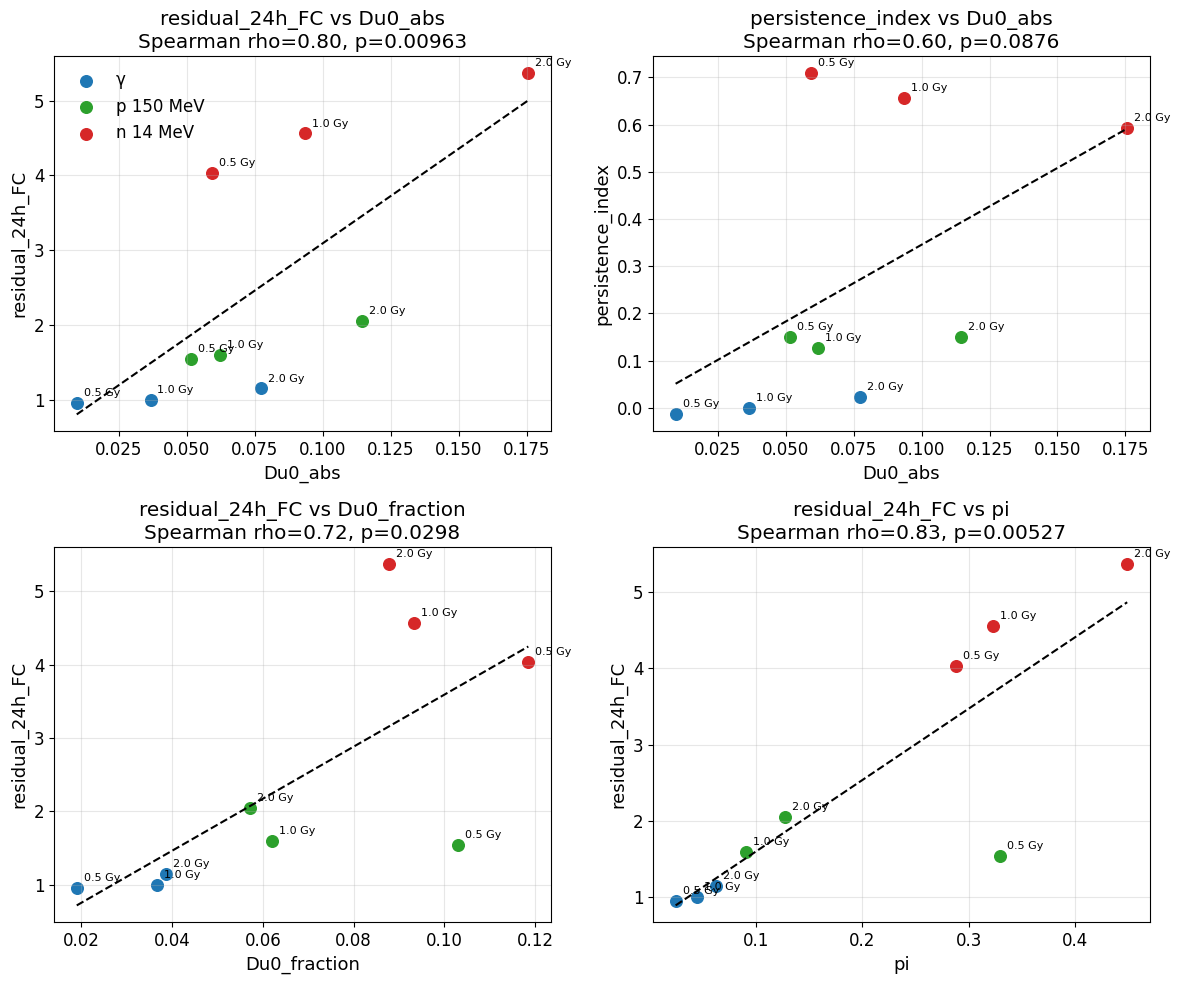

=== Within-radiation correlations (descriptive; n=4 each) ===


,radiation,RAD51_metric,model_feature,spearman_rho,p_value,n
0,gamma,residual_24h_FC,pi,1.0,0.000000,3
1,gamma,residual_24h_FC,Du0_fraction,1.0,0.000000,3
2,gamma,residual_24h_FC,Du0_abs,1.0,0.000000,3
3,gamma,persistence_index,pi,1.0,0.000000,3
4,gamma,persistence_index,Du0_fraction,1.0,0.000000,3
5,gamma,persistence_index,Du0_abs,1.0,0.000000,3
6,proton_150MeV,residual_24h_FC,pi,-0.5,0.666667,3
7,proton_150MeV,residual_24h_FC,Du0_fraction,-1.0,0.000000,3
8,proton_150MeV,residual_24h_FC,Du0_abs,1.0,0.000000,3
9,proton_150MeV,persistence_index,pi,0.5,0.666667,3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress
from IPython.display import display

# =========================================================
# 0. CHECK: RAD51 summary table from previous cell
# expected columns in df_summary:
# ['radiation', 'dose_Gy',
#  'peak_time_h_(2_6h_window)', 'peak_RAD51_raw_(2_6h)',
#  'peak_delta_vs_ctrl_(2_6h)', 'residual_24h_delta',
#  'residual_24h_FC', 'persistence_index', 'AUC_delta_0.5_24h', ...]
# =========================================================

required_cols = {
    "radiation", "dose_Gy",
    "peak_delta_vs_ctrl_(2_6h)",
    "residual_24h_delta",
    "residual_24h_FC",
    "persistence_index",
    "AUC_delta_0.5_24h"
}

missing = required_cols - set(df_summary.columns)
if missing:
    raise ValueError(f"df_summary is missing columns: {missing}")

# =========================================================
# 1. MODEL FEATURES FROM YOUR SEPARATE FITS
#    (main model only; no patched variants)
# =========================================================

# gamma separate fits
gamma_fit = [
    {"radiation": "gamma", "dose_Gy": 0.25, "alpha": 0.134241, "pi": 0.056817},
    {"radiation": "gamma", "dose_Gy": 0.50, "alpha": 0.231623, "pi": 0.024713},
    {"radiation": "gamma", "dose_Gy": 1.00, "alpha": 0.190034, "pi": 0.045250},
    {"radiation": "gamma", "dose_Gy": 2.00, "alpha": 0.385335, "pi": 0.063004},
]

# neutron separate fits
neutron_fit = [
    {"radiation": "neutron_14MeV", "dose_Gy": 0.25, "alpha": 0.578154, "pi": 0.312767},
    {"radiation": "neutron_14MeV", "dose_Gy": 0.50, "alpha": 0.588580, "pi": 0.288091},
    {"radiation": "neutron_14MeV", "dose_Gy": 1.00, "alpha": 0.710574, "pi": 0.322786},
    {"radiation": "neutron_14MeV", "dose_Gy": 2.00, "alpha": 0.804320, "pi": 0.448824},
]

# proton separate fits
proton_fit = [
    {"radiation": "proton_150MeV", "dose_Gy": 0.25, "alpha": 0.338224, "pi": 0.161725},
    {"radiation": "proton_150MeV", "dose_Gy": 0.50, "alpha": 0.687007, "pi": 0.329032},
    {"radiation": "proton_150MeV", "dose_Gy": 1.00, "alpha": 0.319425, "pi": 0.091171},
    {"radiation": "proton_150MeV", "dose_Gy": 2.00, "alpha": 0.552002, "pi": 0.127730},
]

df_model = pd.DataFrame(gamma_fit + neutron_fit + proton_fit)

# derived quantities
df_model["slow_pool"] = 1.0 - df_model["alpha"]
df_model["Du0_fraction"] = df_model["slow_pool"] * df_model["pi"]
df_model["Dc0_fraction"] = df_model["slow_pool"] * (1.0 - df_model["pi"])
df_model["Du0_abs"] = df_model["dose_Gy"] * df_model["Du0_fraction"]
df_model["Dc0_abs"] = df_model["dose_Gy"] * df_model["Dc0_fraction"]

print("=== Model feature table ===")
display(df_model)

# =========================================================
# 2. MERGE RAD51 METRICS WITH MODEL FEATURES
# =========================================================
df_merged = pd.merge(
    df_summary,
    df_model,
    on=["radiation", "dose_Gy"],
    how="inner"
)

print("=== Merged RAD51 + model table ===")
display(df_merged)

# =========================================================
# 3. CORRELATION ANALYSIS
# =========================================================
# RAD51 readouts:
rad51_targets = [
    "peak_delta_vs_ctrl_(2_6h)",
    "residual_24h_delta",
    "residual_24h_FC",
    "persistence_index",
    "AUC_delta_0.5_24h",
]

# model predictors:
model_features = [
    "alpha",
    "pi",
    "Dc0_fraction",
    "Du0_fraction",
    "Dc0_abs",
    "Du0_abs",
]

corr_rows = []
for ycol in rad51_targets:
    for xcol in model_features:
        sub = df_merged[[xcol, ycol]].dropna()
        rho, pval = spearmanr(sub[xcol], sub[ycol])
        corr_rows.append({
            "RAD51_metric": ycol,
            "model_feature": xcol,
            "spearman_rho": rho,
            "p_value": pval,
            "n": len(sub)
        })

df_corr = pd.DataFrame(corr_rows).sort_values(
    ["RAD51_metric", "spearman_rho"],
    ascending=[True, False]
).reset_index(drop=True)

print("=== Spearman correlations ===")
display(df_corr)

# =========================================================
# 4. SIMPLE LINEAR FITS (DESCRIPTIVE ONLY)
# =========================================================
reg_rows = []
for ycol in rad51_targets:
    for xcol in model_features:
        sub = df_merged[[xcol, ycol]].dropna()
        lr = linregress(sub[xcol], sub[ycol])
        reg_rows.append({
            "RAD51_metric": ycol,
            "model_feature": xcol,
            "slope": lr.slope,
            "intercept": lr.intercept,
            "r_value": lr.rvalue,
            "r_squared": lr.rvalue**2,
            "p_value": lr.pvalue,
            "n": len(sub),
        })

df_reg = pd.DataFrame(reg_rows).sort_values(
    ["RAD51_metric", "r_squared"],
    ascending=[True, False]
).reset_index(drop=True)

print("=== Descriptive linear fits ===")
display(df_reg)

# =========================================================
# 5. PLOTS
# =========================================================
color_map = {
    "gamma": "tab:blue",
    "proton_150MeV": "tab:green",
    "neutron_14MeV": "tab:red",
}
label_map = {
    "gamma": "γ",
    "proton_150MeV": "p 150 MeV",
    "neutron_14MeV": "n 14 MeV",
}

plot_pairs = [
    ("Du0_abs", "residual_24h_FC"),
    ("Du0_abs", "persistence_index"),
    ("Du0_fraction", "residual_24h_FC"),
    ("pi", "residual_24h_FC"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, plot_pairs):
    for rad in ["gamma", "proton_150MeV", "neutron_14MeV"]:
        sub = df_merged[df_merged["radiation"] == rad]
        ax.scatter(sub[xcol], sub[ycol], s=70, label=label_map[rad], color=color_map[rad])

        # annotate dose
        for _, row in sub.iterrows():
            ax.annotate(
                f'{row["dose_Gy"]} Gy',
                (row[xcol], row[ycol]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

    # overall linear trend
    sub_all = df_merged[[xcol, ycol]].dropna()
    lr = linregress(sub_all[xcol], sub_all[ycol])
    xline = np.linspace(sub_all[xcol].min(), sub_all[xcol].max(), 100)
    yline = lr.intercept + lr.slope * xline
    ax.plot(xline, yline, linestyle="--", linewidth=1.5, color="black")

    rho, pval = spearmanr(sub_all[xcol], sub_all[ycol])
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} vs {xcol}\nSpearman rho={rho:.2f}, p={pval:.3g}")
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. OPTIONAL: WITHIN-RADIATION CORRELATIONS (DESCRIPTIVE ONLY)
# =========================================================
within_rows = []
for rad in ["gamma", "proton_150MeV", "neutron_14MeV"]:
    sub_rad = df_merged[df_merged["radiation"] == rad]
    for ycol in ["residual_24h_FC", "persistence_index"]:
        for xcol in ["pi", "Du0_fraction", "Du0_abs"]:
            rho, pval = spearmanr(sub_rad[xcol], sub_rad[ycol])
            within_rows.append({
                "radiation": rad,
                "RAD51_metric": ycol,
                "model_feature": xcol,
                "spearman_rho": rho,
                "p_value": pval,
                "n": len(sub_rad)
            })

df_within = pd.DataFrame(within_rows)
print("=== Within-radiation correlations (descriptive; n=4 each) ===")
display(df_within)

=== Combined table ===


,radiation,dose_Gy,peak_time_h,peak_RAD51_raw,peak_delta_vs_ctrl,residual_24h_delta,residual_24h_FC,persistence_index,AUC_delta_0p5_24h,AUC_delta_6_24h,...,pi,slow_pool,Du0_fraction,Dc0_fraction,Du0_abs,Dc0_abs,gh2ax_24h_raw,patm_24h_raw,gh2ax_persist_24_over_6,patm_persist_24_over_6
0,gamma,0.5,6.0,5.64,4.29,-0.06,0.954545,-0.013986,52.3025,38.61,...,0.024713,0.768377,0.018989,0.749388,0.009494,0.374694,2.65,0.93,0.437294,0.328622
1,gamma,1.0,6.0,7.65,6.30,0.00,1.000000,0.000000,78.4625,56.70,...,0.045250,0.809966,0.036651,0.773315,0.036651,0.773315,2.54,1.21,0.308627,0.361194
2,gamma,2.0,6.0,10.23,8.88,0.20,1.151515,0.022523,110.5550,81.72,...,0.063004,0.614665,0.038726,0.575939,0.077453,1.151877,2.67,1.33,0.213089,0.287879
3,proton_150MeV,0.5,6.0,6.17,4.82,0.72,1.545455,0.149378,66.7200,49.86,...,0.329032,0.312993,0.102985,0.210008,0.051492,0.105004,3.22,1.06,0.478455,0.319277
4,proton_150MeV,1.0,6.0,7.57,6.22,0.79,1.598485,0.127010,85.5425,63.09,...,0.091171,0.680575,0.062049,0.618526,0.062049,0.618526,3.24,1.82,0.394641,0.430260
5,proton_150MeV,2.0,6.0,10.57,9.22,1.39,2.053030,0.150759,125.5575,95.49,...,0.127730,0.447998,0.057223,0.390775,0.114446,0.781550,3.48,2.24,0.275099,0.317730
6,neutron_14MeV,0.5,6.0,7.01,5.66,4.01,4.037879,0.708481,105.4550,87.03,...,0.288091,0.411420,0.118526,0.292894,0.059263,0.146447,6.00,2.41,0.792602,0.682720
7,neutron_14MeV,1.0,6.0,8.51,7.16,4.70,4.560606,0.656425,133.0525,106.74,...,0.322786,0.289426,0.093423,0.196003,0.093423,0.196003,6.46,2.96,0.719376,0.573643
8,neutron_14MeV,2.0,6.0,11.07,9.72,5.76,5.363636,0.592593,173.0675,139.32,...,0.448824,0.195680,0.087826,0.107854,0.175652,0.215708,7.97,3.77,0.650082,0.440421



=== Correlations ===


,RAD51_metric,predictor,spearman_rho,p_value,n
0,AUC_delta_0p5_24h,Du0_abs,0.950000,0.000088,9
1,AUC_delta_0p5_24h,patm_24h_raw,0.916667,0.000507,9
2,AUC_delta_0p5_24h,gh2ax_24h_raw,0.800000,0.009628,9
3,AUC_delta_0p5_24h,pi,0.566667,0.111633,9
4,AUC_delta_0p5_24h,Du0_fraction,0.316667,0.406397,9
5,AUC_delta_0p5_24h,patm_persist_24_over_6,0.266667,0.487922,9
6,AUC_delta_0p5_24h,gh2ax_persist_24_over_6,0.150000,0.700094,9
7,late_fraction_score,gh2ax_24h_raw,0.850000,0.003705,9
8,late_fraction_score,pi,0.750000,0.019942,9
9,late_fraction_score,Du0_fraction,0.733333,0.024554,9



=== OLS: residual_24h_FC ~ Du0_abs + C(radiation) ===
                            OLS Regression Results                            
Dep. Variable:        residual_24h_FC   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     294.7
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           4.82e-06
Time:                        22:36:51   Log-Likelihood:                 6.2848
No. Observations:                   9   AIC:                            -4.570
Df Residuals:                       5   BIC:                            -3.781
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

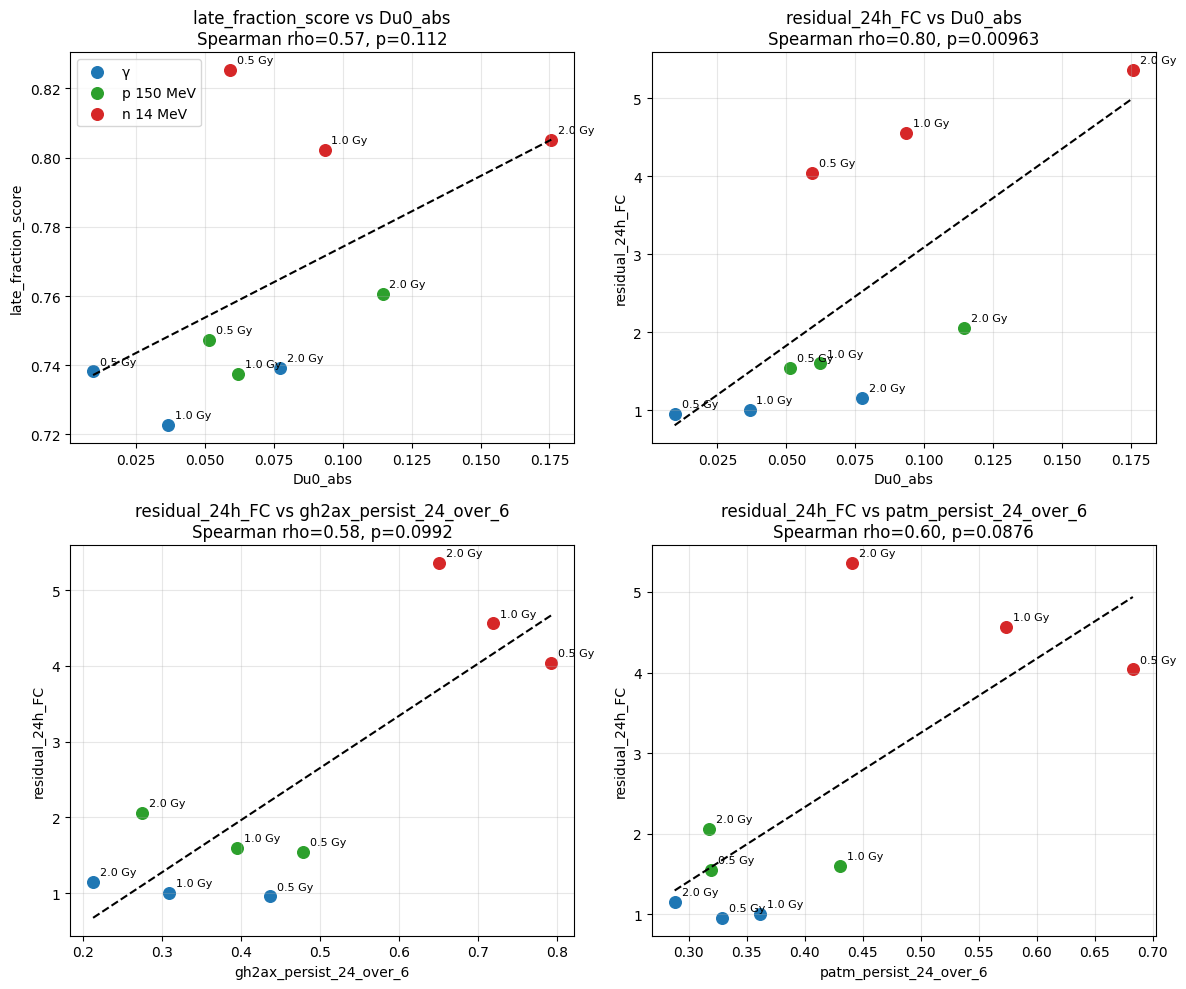

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress
from IPython.display import display

# ------------------------------------------------------------
# 0. Imports for regression
# ------------------------------------------------------------
try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not found: OLS summaries will be skipped.")

# ------------------------------------------------------------
# 1. RAD51 raw data
# ------------------------------------------------------------
t = np.array([0.5, 2.0, 4.0, 6.0, 24.0], dtype=float)

ctrl_mean = np.array([1.23, 1.42, 1.11, 1.35, 1.32], dtype=float)
ctrl_se   = np.array([0.27, 0.31, 0.19, 0.22, 0.25], dtype=float)

RAD51 = {
    "gamma": {
        0.5: {"mean": np.array([1.46, 2.50, 4.78, 5.64, 1.26]), "se": np.array([0.29, 0.45, 0.54, 0.74, 0.28])},
        1.0: {"mean": np.array([1.54, 3.70, 6.73, 7.65, 1.32]), "se": np.array([0.38, 0.58, 0.67, 0.58, 0.33])},
        2.0: {"mean": np.array([1.66, 4.01, 8.66,10.23, 1.52]), "se": np.array([0.46, 0.60, 0.96, 1.17, 0.41])},
    },
    "proton_150MeV": {
        0.5: {"mean": np.array([1.31, 3.50, 5.28, 6.17, 2.04]), "se": np.array([0.39, 0.52, 0.83, 0.71, 0.55])},
        1.0: {"mean": np.array([1.43, 3.89, 6.99, 7.57, 2.11]), "se": np.array([0.33, 0.77, 1.02, 0.91, 0.71])},
        2.0: {"mean": np.array([1.51, 4.23, 8.97,10.57, 2.71]), "se": np.array([0.42, 0.89, 1.26, 0.99, 0.83])},
    },
    "neutron_14MeV": {
        0.5: {"mean": np.array([1.32, 2.95, 6.12, 7.01, 5.33]), "se": np.array([0.44, 0.59, 0.87, 0.93, 0.64])},
        1.0: {"mean": np.array([1.89, 4.71, 7.56, 8.51, 6.02]), "se": np.array([0.63, 0.87, 1.02, 1.36, 0.92])},
        2.0: {"mean": np.array([2.13, 5.37, 9.33,11.07, 7.08]), "se": np.array([0.57, 1.13, 1.54, 1.33, 1.01])},
    }
}

# ------------------------------------------------------------
# 2. Model features from separate fits
# ------------------------------------------------------------
gamma_fit = [
    {"radiation": "gamma", "dose_Gy": 0.50, "alpha": 0.231623, "pi": 0.024713},
    {"radiation": "gamma", "dose_Gy": 1.00, "alpha": 0.190034, "pi": 0.045250},
    {"radiation": "gamma", "dose_Gy": 2.00, "alpha": 0.385335, "pi": 0.063004},
]

proton_fit = [
    {"radiation": "proton_150MeV", "dose_Gy": 0.50, "alpha": 0.687007, "pi": 0.329032},
    {"radiation": "proton_150MeV", "dose_Gy": 1.00, "alpha": 0.319425, "pi": 0.091171},
    {"radiation": "proton_150MeV", "dose_Gy": 2.00, "alpha": 0.552002, "pi": 0.127730},
]

neutron_fit = [
    {"radiation": "neutron_14MeV", "dose_Gy": 0.50, "alpha": 0.588580, "pi": 0.288091},
    {"radiation": "neutron_14MeV", "dose_Gy": 1.00, "alpha": 0.710574, "pi": 0.322786},
    {"radiation": "neutron_14MeV", "dose_Gy": 2.00, "alpha": 0.804320, "pi": 0.448824},
]

df_model = pd.DataFrame(gamma_fit + proton_fit + neutron_fit)
df_model["slow_pool"] = 1.0 - df_model["alpha"]
df_model["Du0_fraction"] = df_model["slow_pool"] * df_model["pi"]
df_model["Dc0_fraction"] = df_model["slow_pool"] * (1.0 - df_model["pi"])
df_model["Du0_abs"] = df_model["dose_Gy"] * df_model["Du0_fraction"]
df_model["Dc0_abs"] = df_model["dose_Gy"] * df_model["Dc0_fraction"]

# ------------------------------------------------------------
# 3. γH2AX and pATM late markers from experimental datasets
#    (raw 24 h and persistence 24 h / 6 h)
# ------------------------------------------------------------
MARKERS = {
    "gamma": {
        0.5: {"gh2ax_6h": 6.06, "gh2ax_24h": 2.65, "patm_6h": 2.83, "patm_24h": 0.93},
        1.0: {"gh2ax_6h": 8.23, "gh2ax_24h": 2.54, "patm_6h": 3.35, "patm_24h": 1.21},
        2.0: {"gh2ax_6h": 12.53, "gh2ax_24h": 2.67, "patm_6h": 4.62, "patm_24h": 1.33},
    },
    "proton_150MeV": {
        0.5: {"gh2ax_6h": 6.73, "gh2ax_24h": 3.22, "patm_6h": 3.32, "patm_24h": 1.06},
        1.0: {"gh2ax_6h": 8.21, "gh2ax_24h": 3.24, "patm_6h": 4.23, "patm_24h": 1.82},
        2.0: {"gh2ax_6h": 12.65, "gh2ax_24h": 3.48, "patm_6h": 7.05, "patm_24h": 2.24},
    },
    "neutron_14MeV": {
        0.5: {"gh2ax_6h": 7.57, "gh2ax_24h": 6.00, "patm_6h": 3.53, "patm_24h": 2.41},
        1.0: {"gh2ax_6h": 8.98, "gh2ax_24h": 6.46, "patm_6h": 5.16, "patm_24h": 2.96},
        2.0: {"gh2ax_6h": 12.26, "gh2ax_24h": 7.97, "patm_6h": 8.56, "patm_24h": 3.77},
    }
}

marker_rows = []
for rad, dose_dict in MARKERS.items():
    for dose, vals in dose_dict.items():
        marker_rows.append({
            "radiation": rad,
            "dose_Gy": dose,
            "gh2ax_24h_raw": vals["gh2ax_24h"],
            "patm_24h_raw": vals["patm_24h"],
            "gh2ax_persist_24_over_6": vals["gh2ax_24h"] / vals["gh2ax_6h"],
            "patm_persist_24_over_6": vals["patm_24h"] / vals["patm_6h"],
        })

df_markers = pd.DataFrame(marker_rows)

# ------------------------------------------------------------
# 4. Build RAD51 summary with late-fraction score
# ------------------------------------------------------------
summary_rows = []

for rad, dose_dict in RAD51.items():
    for dose, vals in dose_dict.items():
        mean = vals["mean"]
        se = vals["se"]

        delta = mean - ctrl_mean
        delta_pos = np.maximum(delta, 0.0)
        fc = mean / ctrl_mean

        # peak in 2-6 h window
        mask_peak = np.isin(t, [2.0, 4.0, 6.0])
        peak_idx_local = np.argmax(delta[mask_peak])
        peak_time = t[mask_peak][peak_idx_local]
        peak_delta = delta[mask_peak][peak_idx_local]
        peak_raw = mean[mask_peak][peak_idx_local]

        residual_24h_delta = delta[-1]
        residual_24h_FC = fc[-1]

        persistence_index = np.nan
        if peak_delta > 0:
            persistence_index = residual_24h_delta / peak_delta

        auc_total = np.trapezoid(delta_pos, t)
        mask_late = t >= 6.0
        auc_late = np.trapezoid(delta_pos[mask_late], t[mask_late])
        late_fraction_score = auc_late / auc_total if auc_total > 0 else np.nan

        summary_rows.append({
            "radiation": rad,
            "dose_Gy": dose,
            "peak_time_h": peak_time,
            "peak_RAD51_raw": peak_raw,
            "peak_delta_vs_ctrl": peak_delta,
            "residual_24h_delta": residual_24h_delta,
            "residual_24h_FC": residual_24h_FC,
            "persistence_index": persistence_index,
            "AUC_delta_0p5_24h": auc_total,
            "AUC_delta_6_24h": auc_late,
            "late_fraction_score": late_fraction_score,
        })

df_rad51_summary = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 5. Merge everything
# ------------------------------------------------------------
df_all = (
    df_rad51_summary
    .merge(df_model, on=["radiation", "dose_Gy"], how="inner")
    .merge(df_markers, on=["radiation", "dose_Gy"], how="inner")
)

print("=== Combined table ===")
display(df_all)

# ------------------------------------------------------------
# 6. Correlations
# ------------------------------------------------------------
rad51_targets = [
    "residual_24h_FC",
    "residual_24h_delta",
    "persistence_index",
    "AUC_delta_0p5_24h",
    "late_fraction_score",
]

predictors = [
    "pi",
    "Du0_fraction",
    "Du0_abs",
    "gh2ax_24h_raw",
    "patm_24h_raw",
    "gh2ax_persist_24_over_6",
    "patm_persist_24_over_6",
]

corr_rows = []
for ycol in rad51_targets:
    for xcol in predictors:
        sub = df_all[[xcol, ycol]].dropna()
        rho, pval = spearmanr(sub[xcol], sub[ycol])
        corr_rows.append({
            "RAD51_metric": ycol,
            "predictor": xcol,
            "spearman_rho": rho,
            "p_value": pval,
            "n": len(sub)
        })

df_corr = pd.DataFrame(corr_rows).sort_values(
    ["RAD51_metric", "spearman_rho"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n=== Correlations ===")
display(df_corr)

# ------------------------------------------------------------
# 7. Regression: RAD51 ~ Du0_abs + radiation
# ------------------------------------------------------------
if HAS_STATSMODELS:
    print("\n=== OLS: residual_24h_FC ~ Du0_abs + C(radiation) ===")
    model1 = smf.ols("residual_24h_FC ~ Du0_abs + C(radiation)", data=df_all).fit()
    print(model1.summary())

    print("\n=== OLS: AUC_delta_0p5_24h ~ Du0_abs + C(radiation) ===")
    model2 = smf.ols("AUC_delta_0p5_24h ~ Du0_abs + C(radiation)", data=df_all).fit()
    print(model2.summary())

    print("\n=== OLS: residual_24h_FC ~ pi + C(radiation) ===")
    model3 = smf.ols("residual_24h_FC ~ pi + C(radiation)", data=df_all).fit()
    print(model3.summary())
else:
    print("\nInstall statsmodels to run OLS with categorical radiation effects.")

# ------------------------------------------------------------
# 8. Plots
# ------------------------------------------------------------
color_map = {
    "gamma": "tab:blue",
    "proton_150MeV": "tab:green",
    "neutron_14MeV": "tab:red",
}
label_map = {
    "gamma": "γ",
    "proton_150MeV": "p 150 MeV",
    "neutron_14MeV": "n 14 MeV",
}

plot_pairs = [
    ("Du0_abs", "late_fraction_score"),
    ("Du0_abs", "residual_24h_FC"),
    ("gh2ax_persist_24_over_6", "residual_24h_FC"),
    ("patm_persist_24_over_6", "residual_24h_FC"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, plot_pairs):
    for rad in ["gamma", "proton_150MeV", "neutron_14MeV"]:
        sub = df_all[df_all["radiation"] == rad]
        ax.scatter(sub[xcol], sub[ycol], s=70, label=label_map[rad], color=color_map[rad])

        for _, row in sub.iterrows():
            ax.annotate(
                f'{row["dose_Gy"]} Gy',
                (row[xcol], row[ycol]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

    sub_all = df_all[[xcol, ycol]].dropna()
    rho, pval = spearmanr(sub_all[xcol], sub_all[ycol])

    # line only for eye guidance
    lr = linregress(sub_all[xcol], sub_all[ycol])
    xline = np.linspace(sub_all[xcol].min(), sub_all[xcol].max(), 100)
    yline = lr.intercept + lr.slope * xline
    ax.plot(xline, yline, "--", linewidth=1.5, color="black")

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} vs {xcol}\nSpearman rho={rho:.2f}, p={pval:.3g}")
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

=== Robustness summary ===


,x,y,n,rho_obs,rho_p_obs,rho_perm_p,rho_boot_2.5%,rho_boot_50%,rho_boot_97.5%,slope_obs,slope_p_obs,slope_boot_2.5%,slope_boot_50%,slope_boot_97.5%,LOO_rho_min,LOO_rho_max,LOO_slope_min,LOO_slope_max
0,gh2ax_24h_raw,residual_24h_FC,9,0.983333,0.000002,0.0000,0.816514,1.000000,1.0,0.841683,1.896553e-08,0.792622,0.841939,0.938968,0.976190,1.000000,0.820919,0.902113
1,Du0_abs,AUC_delta_0p5_24h,9,0.950000,0.000088,0.0002,0.721739,0.947368,1.0,736.424402,6.532257e-05,630.545874,737.262462,1004.556813,0.928571,0.952381,708.062419,797.580597
2,patm_24h_raw,residual_24h_FC,9,0.950000,0.000088,0.0004,0.624742,0.982609,1.0,1.669551,1.328825e-04,1.005512,1.679192,2.104823,0.928571,1.000000,1.592895,1.762977
3,Du0_abs,residual_24h_FC,9,0.800000,0.009628,0.0160,0.178493,0.824561,1.0,25.270711,2.910528e-02,4.722587,25.661151,44.968748,0.714286,0.904762,19.854400,28.872483



=== Leave-one-out: residual_24h_FC vs Du0_abs ===


,x,y,removed_radiation,removed_dose_Gy,rho_LOO,rho_p_LOO,slope_LOO,r2_LOO
0,Du0_abs,residual_24h_FC,gamma,0.5,0.714286,0.046528,26.074561,0.457376
1,Du0_abs,residual_24h_FC,gamma,1.0,0.714286,0.046528,24.011165,0.474111
2,Du0_abs,residual_24h_FC,neutron_14MeV,2.0,0.714286,0.046528,19.854400,0.213953
3,Du0_abs,residual_24h_FC,neutron_14MeV,1.0,0.761905,0.028005,23.483740,0.554870
4,Du0_abs,residual_24h_FC,proton_150MeV,0.5,0.785714,0.020815,24.791633,0.500973
5,Du0_abs,residual_24h_FC,proton_150MeV,2.0,0.833333,0.010176,28.872483,0.618572
6,Du0_abs,residual_24h_FC,proton_150MeV,1.0,0.833333,0.010176,24.833407,0.512559
7,Du0_abs,residual_24h_FC,gamma,2.0,0.880952,0.003850,25.427388,0.571482
8,Du0_abs,residual_24h_FC,neutron_14MeV,0.5,0.904762,0.002008,27.231037,0.669916



=== Leave-one-out: AUC_delta_0p5_24h vs Du0_abs ===


,x,y,removed_radiation,removed_dose_Gy,rho_LOO,rho_p_LOO,slope_LOO,r2_LOO
0,Du0_abs,AUC_delta_0p5_24h,gamma,0.5,0.928571,0.000863,723.185681,0.879377
1,Du0_abs,AUC_delta_0p5_24h,gamma,2.0,0.928571,0.000863,735.768368,0.913134
2,Du0_abs,AUC_delta_0p5_24h,neutron_14MeV,2.0,0.928571,0.000863,797.580597,0.832754
3,Du0_abs,AUC_delta_0p5_24h,gamma,1.0,0.952381,0.000260,745.900078,0.905877
4,Du0_abs,AUC_delta_0p5_24h,proton_150MeV,1.0,0.952381,0.000260,729.934251,0.913896
5,Du0_abs,AUC_delta_0p5_24h,proton_150MeV,2.0,0.952381,0.000260,753.103835,0.910527
6,Du0_abs,AUC_delta_0p5_24h,neutron_14MeV,0.5,0.952381,0.000260,750.350742,0.930381
7,Du0_abs,AUC_delta_0p5_24h,proton_150MeV,0.5,0.952381,0.000260,708.062419,0.939644
8,Du0_abs,AUC_delta_0p5_24h,neutron_14MeV,1.0,0.952381,0.000260,718.417062,0.932119



=== Leave-one-out: residual_24h_FC vs gh2ax_24h_raw ===


,x,y,removed_radiation,removed_dose_Gy,rho_LOO,rho_p_LOO,slope_LOO,r2_LOO
0,gh2ax_24h_raw,residual_24h_FC,proton_150MeV,0.5,0.97619,0.000033,0.839337,0.990986
1,gh2ax_24h_raw,residual_24h_FC,gamma,2.0,0.97619,0.000033,0.842018,0.990343
2,gh2ax_24h_raw,residual_24h_FC,proton_150MeV,2.0,0.97619,0.000033,0.847808,0.993621
3,gh2ax_24h_raw,residual_24h_FC,proton_150MeV,1.0,0.97619,0.000033,0.840698,0.990858
4,gh2ax_24h_raw,residual_24h_FC,neutron_14MeV,0.5,0.97619,0.000033,0.835619,0.990460
5,gh2ax_24h_raw,residual_24h_FC,neutron_14MeV,1.0,0.97619,0.000033,0.820919,0.992534
6,gh2ax_24h_raw,residual_24h_FC,neutron_14MeV,2.0,0.97619,0.000033,0.902113,0.994426
7,gh2ax_24h_raw,residual_24h_FC,gamma,0.5,1.00000,0.000000,0.831072,0.991872
8,gh2ax_24h_raw,residual_24h_FC,gamma,1.0,1.00000,0.000000,0.839278,0.990199



=== Leave-one-out: residual_24h_FC vs patm_24h_raw ===


,x,y,removed_radiation,removed_dose_Gy,rho_LOO,rho_p_LOO,slope_LOO,r2_LOO
0,patm_24h_raw,residual_24h_FC,gamma,0.5,0.928571,0.000863,1.710568,0.879591
1,patm_24h_raw,residual_24h_FC,neutron_14MeV,0.5,0.928571,0.000863,1.612438,0.914595
2,patm_24h_raw,residual_24h_FC,proton_150MeV,2.0,0.928571,0.000863,1.705702,0.926995
3,patm_24h_raw,residual_24h_FC,proton_150MeV,1.0,0.928571,0.000863,1.655262,0.905862
4,patm_24h_raw,residual_24h_FC,neutron_14MeV,1.0,0.928571,0.000863,1.592895,0.874576
5,patm_24h_raw,residual_24h_FC,neutron_14MeV,2.0,0.928571,0.000863,1.731718,0.817792
6,patm_24h_raw,residual_24h_FC,gamma,2.0,0.976190,0.000033,1.643232,0.883822
7,patm_24h_raw,residual_24h_FC,gamma,1.0,0.976190,0.000033,1.643603,0.879924
8,patm_24h_raw,residual_24h_FC,proton_150MeV,0.5,1.000000,0.000000,1.762977,0.905779


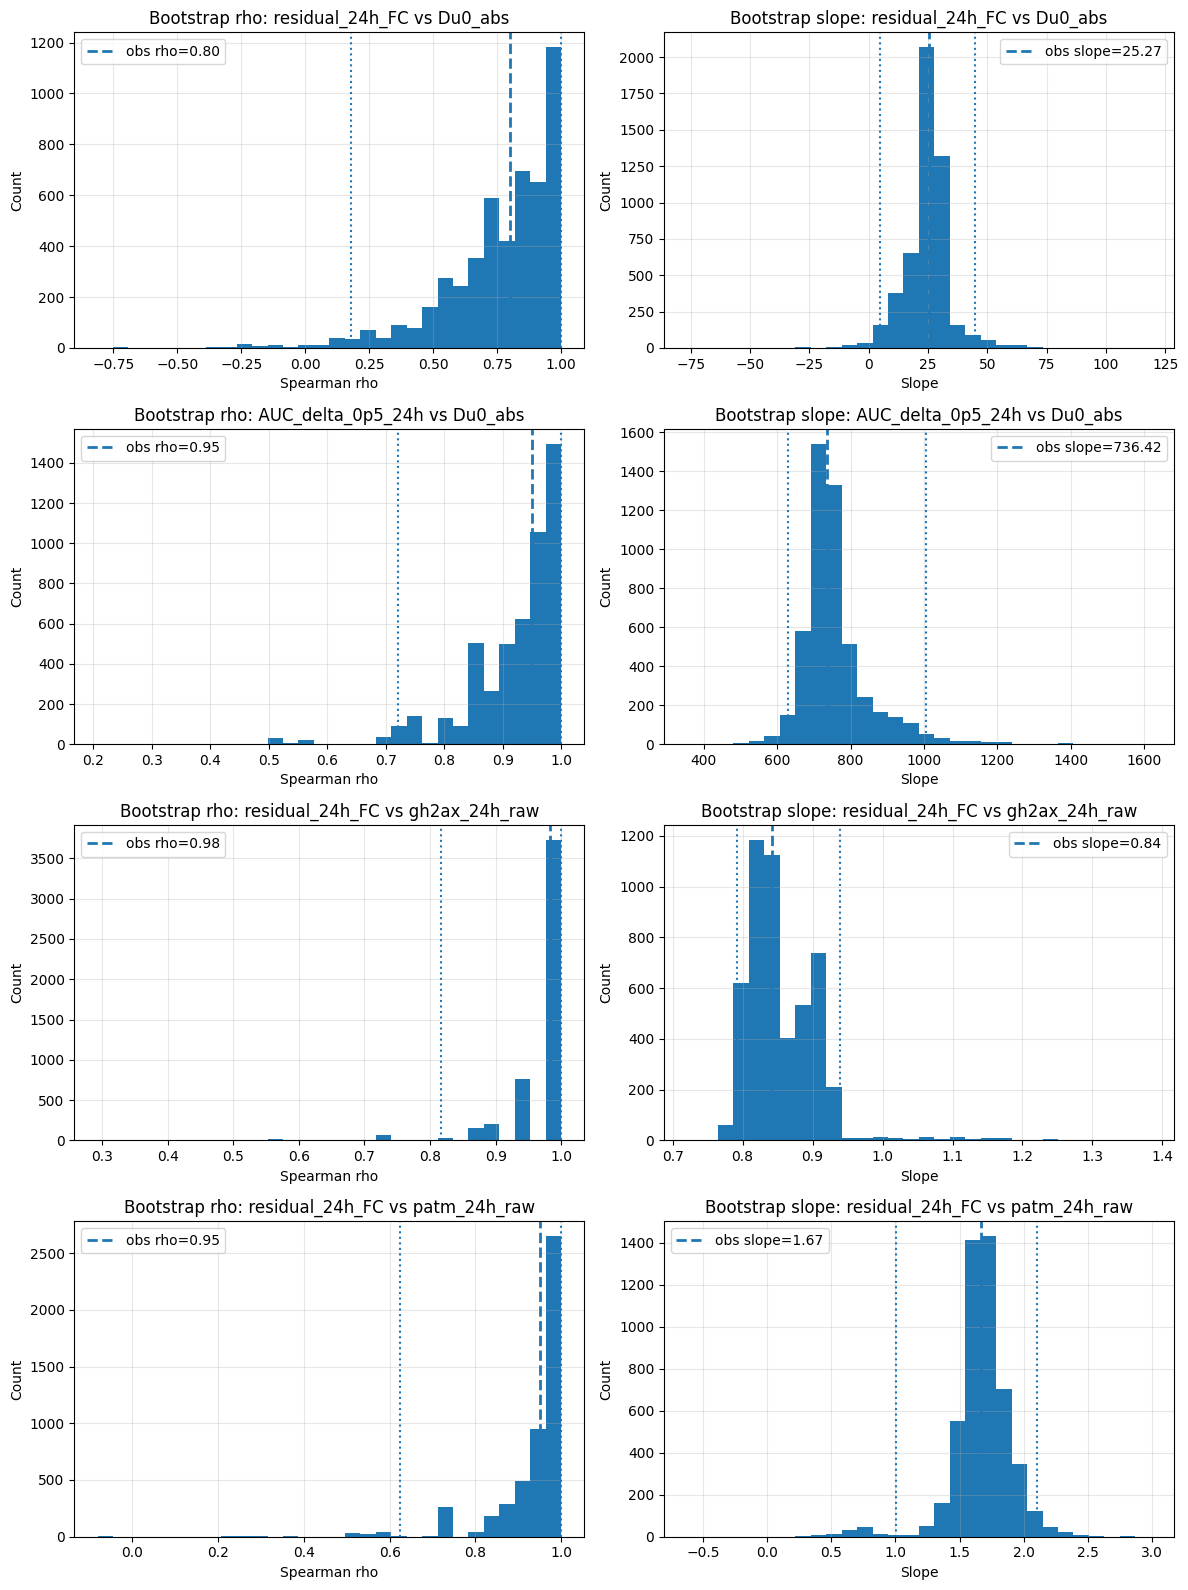


=== Quick stability flags ===


,pair,rho_positive_boot_CI,slope_positive_boot_CI,rho_positive_in_all_LOO
0,residual_24h_FC ~ gh2ax_24h_raw,True,True,True
1,AUC_delta_0p5_24h ~ Du0_abs,True,True,True
2,residual_24h_FC ~ patm_24h_raw,True,True,True
3,residual_24h_FC ~ Du0_abs,True,True,True


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress
from IPython.display import display

# =========================================================
# Robustness analysis for key RAD51 relationships
# Requires: df_all from the previous cell
# =========================================================

if "df_all" not in globals():
    raise ValueError("df_all not found. Run the previous merged-analysis cell first.")

# -----------------------------
# Choose the key relationships
# -----------------------------
PAIRS = [
    ("Du0_abs", "residual_24h_FC"),
    ("Du0_abs", "AUC_delta_0p5_24h"),
    ("gh2ax_24h_raw", "residual_24h_FC"),
    ("patm_24h_raw", "residual_24h_FC"),
]

BOOT_N = 5000
PERM_N = 5000
RNG = np.random.default_rng(42)

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def calc_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    rho, p_rho = spearmanr(x, y)
    lr = linregress(x, y)

    return {
        "rho": float(rho),
        "rho_p": float(p_rho),
        "slope": float(lr.slope),
        "intercept": float(lr.intercept),
        "r_value": float(lr.rvalue),
        "r_squared": float(lr.rvalue**2),
        "slope_p": float(lr.pvalue),
    }

def bootstrap_stats(x, y, n_boot=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    rho_vals = []
    slope_vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        yb = y[idx]

        # if all x are the same after resampling, skip
        if np.allclose(xb, xb[0]):
            continue

        rho, _ = spearmanr(xb, yb)
        lr = linregress(xb, yb)

        if np.isfinite(rho) and np.isfinite(lr.slope):
            rho_vals.append(rho)
            slope_vals.append(lr.slope)

    rho_vals = np.array(rho_vals, dtype=float)
    slope_vals = np.array(slope_vals, dtype=float)

    out = {
        "rho_boot": rho_vals,
        "slope_boot": slope_vals,
        "rho_ci_low": np.percentile(rho_vals, 2.5),
        "rho_ci_med": np.percentile(rho_vals, 50),
        "rho_ci_high": np.percentile(rho_vals, 97.5),
        "slope_ci_low": np.percentile(slope_vals, 2.5),
        "slope_ci_med": np.percentile(slope_vals, 50),
        "slope_ci_high": np.percentile(slope_vals, 97.5),
    }
    return out

def permutation_test_rho(x, y, n_perm=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    rho_obs, _ = spearmanr(x, y)
    perm_rhos = []

    for _ in range(n_perm):
        yp = rng.permutation(y)
        rho_p, _ = spearmanr(x, yp)
        perm_rhos.append(rho_p)

    perm_rhos = np.array(perm_rhos, dtype=float)
    p_two_sided = np.mean(np.abs(perm_rhos) >= np.abs(rho_obs))

    return {
        "rho_obs": float(rho_obs),
        "perm_p_two_sided": float(p_two_sided),
        "perm_rhos": perm_rhos,
    }

def leave_one_out_table(df, xcol, ycol):
    rows = []
    n = len(df)

    for i in range(n):
        sub = df.drop(df.index[i]).copy()
        stats_i = calc_stats(sub[xcol], sub[ycol])

        removed = df.iloc[i]
        rows.append({
            "x": xcol,
            "y": ycol,
            "removed_radiation": removed["radiation"],
            "removed_dose_Gy": removed["dose_Gy"],
            "rho_LOO": stats_i["rho"],
            "rho_p_LOO": stats_i["rho_p"],
            "slope_LOO": stats_i["slope"],
            "r2_LOO": stats_i["r_squared"],
        })

    return pd.DataFrame(rows)

# ---------------------------------------------------------
# Main analysis
# ---------------------------------------------------------
summary_rows = []
loo_tables = {}
boot_store = {}
perm_store = {}

for xcol, ycol in PAIRS:
    sub = df_all[[xcol, ycol, "radiation", "dose_Gy"]].dropna().copy()

    obs = calc_stats(sub[xcol], sub[ycol])
    boot = bootstrap_stats(sub[xcol].values, sub[ycol].values, n_boot=BOOT_N, rng=RNG)
    perm = permutation_test_rho(sub[xcol].values, sub[ycol].values, n_perm=PERM_N, rng=RNG)
    loo = leave_one_out_table(sub, xcol, ycol)

    loo_tables[(xcol, ycol)] = loo
    boot_store[(xcol, ycol)] = boot
    perm_store[(xcol, ycol)] = perm

    summary_rows.append({
        "x": xcol,
        "y": ycol,
        "n": len(sub),
        "rho_obs": obs["rho"],
        "rho_p_obs": obs["rho_p"],
        "rho_perm_p": perm["perm_p_two_sided"],
        "rho_boot_2.5%": boot["rho_ci_low"],
        "rho_boot_50%": boot["rho_ci_med"],
        "rho_boot_97.5%": boot["rho_ci_high"],
        "slope_obs": obs["slope"],
        "slope_p_obs": obs["slope_p"],
        "slope_boot_2.5%": boot["slope_ci_low"],
        "slope_boot_50%": boot["slope_ci_med"],
        "slope_boot_97.5%": boot["slope_ci_high"],
        "LOO_rho_min": loo["rho_LOO"].min(),
        "LOO_rho_max": loo["rho_LOO"].max(),
        "LOO_slope_min": loo["slope_LOO"].min(),
        "LOO_slope_max": loo["slope_LOO"].max(),
    })

df_robust = pd.DataFrame(summary_rows).sort_values("rho_obs", ascending=False).reset_index(drop=True)

print("=== Robustness summary ===")
display(df_robust)

# ---------------------------------------------------------
# Show LOO tables
# ---------------------------------------------------------
for key, loo in loo_tables.items():
    xcol, ycol = key
    print(f"\n=== Leave-one-out: {ycol} vs {xcol} ===")
    display(loo.sort_values("rho_LOO", ascending=True).reset_index(drop=True))

# ---------------------------------------------------------
# Plot bootstrap distributions
# ---------------------------------------------------------
fig, axes = plt.subplots(len(PAIRS), 2, figsize=(12, 4 * len(PAIRS)))
if len(PAIRS) == 1:
    axes = np.array([axes])

for i, (xcol, ycol) in enumerate(PAIRS):
    boot = boot_store[(xcol, ycol)]
    obs = df_robust[(df_robust["x"] == xcol) & (df_robust["y"] == ycol)].iloc[0]

    # rho histogram
    ax = axes[i, 0]
    ax.hist(boot["rho_boot"], bins=30)
    ax.axvline(obs["rho_obs"], linestyle="--", linewidth=2, label=f"obs rho={obs['rho_obs']:.2f}")
    ax.axvline(obs["rho_boot_2.5%"], linestyle=":")
    ax.axvline(obs["rho_boot_97.5%"], linestyle=":")
    ax.set_title(f"Bootstrap rho: {ycol} vs {xcol}")
    ax.set_xlabel("Spearman rho")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # slope histogram
    ax = axes[i, 1]
    ax.hist(boot["slope_boot"], bins=30)
    ax.axvline(obs["slope_obs"], linestyle="--", linewidth=2, label=f"obs slope={obs['slope_obs']:.2f}")
    ax.axvline(obs["slope_boot_2.5%"], linestyle=":")
    ax.axvline(obs["slope_boot_97.5%"], linestyle=":")
    ax.set_title(f"Bootstrap slope: {ycol} vs {xcol}")
    ax.set_xlabel("Slope")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Compact interpretation helper
# ---------------------------------------------------------
interp_rows = []
for _, row in df_robust.iterrows():
    rho_stable = row["rho_boot_2.5%"] > 0
    slope_stable = row["slope_boot_2.5%"] > 0
    loo_stable = row["LOO_rho_min"] > 0

    interp_rows.append({
        "pair": f"{row['y']} ~ {row['x']}",
        "rho_positive_boot_CI": rho_stable,
        "slope_positive_boot_CI": slope_stable,
        "rho_positive_in_all_LOO": loo_stable,
    })

df_interp = pd.DataFrame(interp_rows)
print("\n=== Quick stability flags ===")
display(df_interp)

=== RAD51 model comparison by radiation type ===


,radiation,model,chi2,AIC,AICc,k_on,k_mat,k_off,eta_u
0,gamma,M0_Dc_only,216.717206,222.717206,224.899024,10.005641,0.600164,0.060432,NaN
1,gamma,M2_Dc_plus_etaDu,304.679504,312.679504,316.679504,4.701241,1.042501,0.128207,2.075995
2,gamma,M1_Du_only,326.676510,332.676510,334.858329,18.974476,1.171174,0.202098,NaN
3,neutron_14MeV,M1_Du_only,13.711659,19.711659,21.893477,47.600202,0.775941,0.684830,NaN
4,neutron_14MeV,M2_Dc_plus_etaDu,18.484747,26.484747,30.484747,13.984166,0.611566,0.708119,4.014017
5,neutron_14MeV,M0_Dc_only,296.056188,302.056188,304.238006,20.437751,1.173518,0.138994,NaN
6,proton_150MeV,M1_Du_only,97.070941,103.070941,105.252759,18.281632,1.289350,0.203235,NaN
7,proton_150MeV,M2_Dc_plus_etaDu,102.923778,110.923778,114.923778,5.069029,0.987111,0.141759,2.011786
8,proton_150MeV,M0_Dc_only,119.057533,125.057533,127.239351,10.289550,0.614521,0.026244,NaN



=== Best model by radiation ===

gamma:
  best model = M0_Dc_only
  chi2       = 216.71720589770825
  AICc       = 224.89902407952644
  params     = {'k_on': 10.005641277775837, 'k_mat': 0.6001635252436537, 'k_off': 0.060431665425287565}

proton_150MeV:
  best model = M1_Du_only
  chi2       = 97.07094110334467
  AICc       = 105.25275928516285
  params     = {'k_on': 18.281631851972552, 'k_mat': 1.289350050859953, 'k_off': 0.20323524715907373}

neutron_14MeV:
  best model = M1_Du_only
  chi2       = 13.711659154664199
  AICc       = 21.893477336482377
  params     = {'k_on': 47.600201658489674, 'k_mat': 0.7759406830051253, 'k_off': 0.6848296351015614}

=== Condition-level fit quality for best model in each radiation type ===


,radiation,model,dose_Gy,chi2,max_abs_z
0,gamma,M0_Dc_only,0.5,36.555035,4.166936
1,gamma,M0_Dc_only,1.0,144.431422,9.336337
2,gamma,M0_Dc_only,2.0,35.730749,3.934483
3,neutron_14MeV,M1_Du_only,0.5,6.640595,1.684593
4,neutron_14MeV,M1_Du_only,1.0,2.817088,1.210955
5,neutron_14MeV,M1_Du_only,2.0,4.253976,1.527316
6,proton_150MeV,M1_Du_only,0.5,27.259979,3.656845
7,proton_150MeV,M1_Du_only,1.0,36.405661,5.243808
8,proton_150MeV,M1_Du_only,2.0,33.405300,4.601807


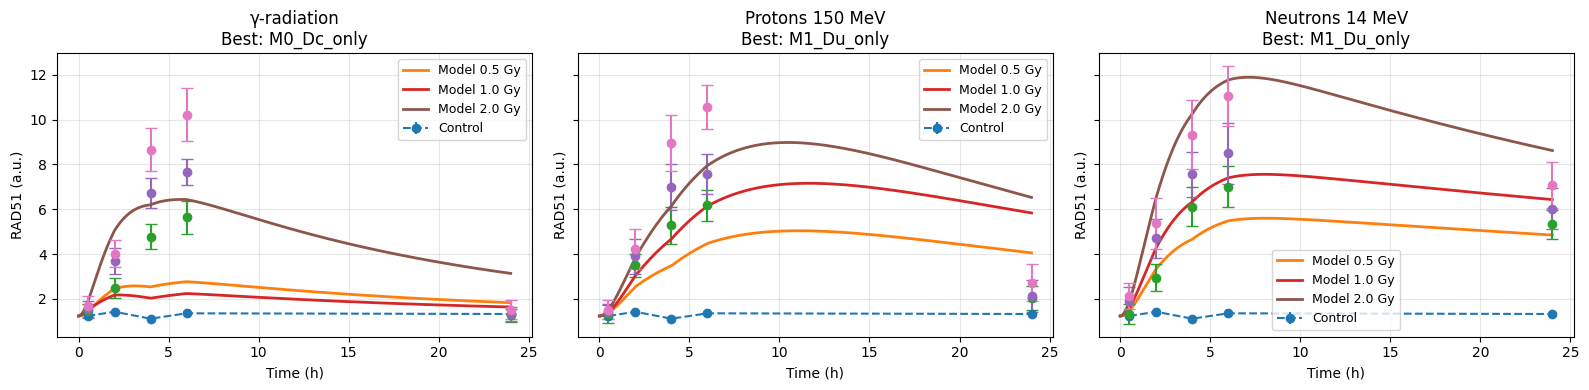

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from IPython.display import display

# =========================================================
# 0. Check required objects from previous cell
# =========================================================
required = ["t_exp", "t_dense", "ctrl_mean", "RAD51_DATA", "CPLUS_PARAMS"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(
        f"Missing objects from previous cell: {missing}\n"
        "Run the previous RAD51/C+ setup cell first."
    )

# =========================================================
# 1. Upstream C+ damage model
# =========================================================
def rhs_cplus(t, y, p):
    D_s, D_c, D_u, pATM_f, pATM_s, gH2AX = y

    dD_s = -p["k_rs"] * D_s
    dD_c = -(p["V_rc"] * D_c) / (p["K_rc"] + D_c + 1e-12) - p["k_cu"] * D_c
    dD_u = -p["k_u"] * D_u + p["k_cu"] * D_c

    w_du = p["s_du"] * p["w_dc"]
    weighted = D_s + p["w_dc"] * D_c + w_du * D_u

    prod_f = (p["V_af"] * weighted) / (p["K_m"] + weighted + 1e-12)
    dpATM_f = prod_f - p["k_df"] * pATM_f
    dpATM_s = p["k_as"] * pATM_f - p["k_ds"] * pATM_s
    dgH2AX = p["k_p"] * (pATM_f + pATM_s) - p["k_g"] * gH2AX

    return [dD_s, dD_c, dD_u, dpATM_f, dpATM_s, dgH2AX]

def simulate_cplus_damage(dose, p, t_eval):
    alpha = float(np.clip(p["alpha"], 0.02, 0.95))
    pi = float(np.clip(p["pi"], 0.0, 0.95))

    D_s0 = alpha * dose
    D_slow0 = (1.0 - alpha) * dose
    D_u0 = pi * D_slow0
    D_c0 = (1.0 - pi) * D_slow0

    y0 = [D_s0, D_c0, D_u0, 0.0, 0.0, 0.0]

    sol = solve_ivp(
        lambda t, y: rhs_cplus(t, y, p),
        (0.0, float(np.max(t_eval))),
        y0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8
    )
    return sol

# precompute upstream trajectories for all conditions
UPSTREAM = {}
for rad, dose_dict in CPLUS_PARAMS.items():
    UPSTREAM[rad] = {}
    for dose, p in dose_dict.items():
        sol = simulate_cplus_damage(dose, p, t_dense)
        UPSTREAM[rad][dose] = {
            "t": t_dense,
            "Dc": sol.y[1].copy(),
            "Du": sol.y[2].copy(),
        }

# =========================================================
# 2. RAD51 downstream module
# =========================================================
def make_source(rad, dose, model_name, pars):
    Dc = UPSTREAM[rad][dose]["Dc"]
    Du = UPSTREAM[rad][dose]["Du"]
    tt = UPSTREAM[rad][dose]["t"]

    if model_name == "M0_Dc_only":
        def source(t):
            return np.interp(t, tt, Dc)
    elif model_name == "M1_Du_only":
        def source(t):
            return np.interp(t, tt, Du)
    elif model_name == "M2_Dc_plus_etaDu":
        eta_u = pars["eta_u"]
        def source(t):
            return np.interp(t, tt, Dc) + eta_u * np.interp(t, tt, Du)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return source

def rhs_rad51(t, y, source_func, pars):
    Q, R = y
    src = max(source_func(t), 0.0)

    dQ = pars["k_on"] * src - pars["k_mat"] * Q
    dR = pars["k_mat"] * Q - pars["k_off"] * R
    return [dQ, dR]

def simulate_rad51(rad, dose, model_name, pars, t_eval):
    source_func = make_source(rad, dose, model_name, pars)
    y0 = [0.0, 0.0]  # excess RAD51 above control

    sol = solve_ivp(
        lambda t, y: rhs_rad51(t, y, source_func, pars),
        (0.0, float(np.max(t_eval))),
        y0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8
    )
    return sol

# =========================================================
# 3. Parameter unpacking
# =========================================================
def unpack_rad51_params(x, model_name):
    if model_name in ["M0_Dc_only", "M1_Du_only"]:
        return {
            "k_on": float(x[0]),
            "k_mat": float(x[1]),
            "k_off": float(x[2]),
        }
    elif model_name == "M2_Dc_plus_etaDu":
        return {
            "k_on": float(x[0]),
            "eta_u": float(x[1]),
            "k_mat": float(x[2]),
            "k_off": float(x[3]),
        }
    else:
        raise ValueError(model_name)

# =========================================================
# 4. Residuals and fit for one radiation type
# =========================================================
def residuals_rad51_one_radiation(x, radiation, model_name):
    pars = unpack_rad51_params(x, model_name)
    res = []

    for dose, vals in RAD51_DATA[radiation].items():
        sol = simulate_rad51(radiation, dose, model_name, pars, t_exp)
        if not sol.success:
            return np.ones(len(RAD51_DATA[radiation]) * len(t_exp)) * 1e3

        pred_excess = sol.y[1]
        pred_total = ctrl_mean + pred_excess

        res.extend((pred_total - vals["mean"]) / (vals["se"] + 1e-12))

    return np.asarray(res, dtype=float)

def fit_one_radiation_model(radiation, model_name):
    if model_name in ["M0_Dc_only", "M1_Du_only"]:
        starts = [
            np.array([2.0, 0.8, 0.08]),
            np.array([5.0, 1.0, 0.12]),
            np.array([10.0, 0.6, 0.06]),
            np.array([20.0, 1.2, 0.15]),
        ]
        lb = np.array([1e-6, 1e-4, 1e-4], dtype=float)
        ub = np.array([100.0, 5.0, 2.0], dtype=float)
    else:
        starts = [
            np.array([2.0, 1.0, 0.8, 0.08]),
            np.array([5.0, 2.0, 1.0, 0.12]),
            np.array([10.0, 3.0, 0.6, 0.06]),
            np.array([20.0, 5.0, 1.2, 0.15]),
        ]
        lb = np.array([1e-6, 0.0, 1e-4, 1e-4], dtype=float)
        ub = np.array([100.0, 20.0, 5.0, 2.0], dtype=float)

    best = None
    best_chi2 = np.inf
    best_start = None

    for x0 in starts:
        res = least_squares(
            lambda x: residuals_rad51_one_radiation(x, radiation, model_name),
            x0,
            bounds=(lb, ub),
            method="trf",
            max_nfev=50000,
            ftol=1e-8,
            xtol=1e-8,
            gtol=1e-8,
            verbose=0
        )
        chi2 = float(np.sum(res.fun ** 2))
        if chi2 < best_chi2:
            best = res
            best_chi2 = chi2
            best_start = x0.copy()

    k = len(best.x)
    n = len(RAD51_DATA[radiation]) * len(t_exp)  # 3 doses * 5 timepoints = 15
    aic = 2 * k + best_chi2
    aicc = aic + 2 * k * (k + 1) / (n - k - 1)

    return {
        "radiation": radiation,
        "model": model_name,
        "res": best,
        "chi2": best_chi2,
        "AIC": aic,
        "AICc": aicc,
        "best_start": best_start,
        "params": unpack_rad51_params(best.x, model_name),
    }

# =========================================================
# 5. Fit all radiation types and all model hypotheses
# =========================================================
radiations = ["gamma", "proton_150MeV", "neutron_14MeV"]
model_names = ["M0_Dc_only", "M1_Du_only", "M2_Dc_plus_etaDu"]

all_fit_results = []
for rad in radiations:
    for model_name in model_names:
        all_fit_results.append(fit_one_radiation_model(rad, model_name))

df_compare = pd.DataFrame([
    {
        "radiation": fr["radiation"],
        "model": fr["model"],
        "chi2": fr["chi2"],
        "AIC": fr["AIC"],
        "AICc": fr["AICc"],
        **fr["params"]
    }
    for fr in all_fit_results
]).sort_values(["radiation", "AICc"]).reset_index(drop=True)

print("=== RAD51 model comparison by radiation type ===")
display(df_compare)

# =========================================================
# 6. Best model for each radiation
# =========================================================
best_by_rad = {}
for rad in radiations:
    sub = [fr for fr in all_fit_results if fr["radiation"] == rad]
    best_by_rad[rad] = sorted(sub, key=lambda x: x["AICc"])[0]

print("\n=== Best model by radiation ===")
for rad in radiations:
    fr = best_by_rad[rad]
    print(f"\n{rad}:")
    print("  best model =", fr["model"])
    print("  chi2       =", fr["chi2"])
    print("  AICc       =", fr["AICc"])
    print("  params     =", fr["params"])

# =========================================================
# 7. Condition-level fit quality for each best model
# =========================================================
rows = []
for rad in radiations:
    fr = best_by_rad[rad]
    model_name = fr["model"]
    pars = fr["params"]

    for dose, vals in RAD51_DATA[rad].items():
        sol = simulate_rad51(rad, dose, model_name, pars, t_exp)
        pred_total = ctrl_mean + sol.y[1]
        z = (pred_total - vals["mean"]) / (vals["se"] + 1e-12)

        rows.append({
            "radiation": rad,
            "model": model_name,
            "dose_Gy": dose,
            "chi2": float(np.sum(z**2)),
            "max_abs_z": float(np.max(np.abs(z)))
        })

df_cond = pd.DataFrame(rows).sort_values(["radiation", "dose_Gy"]).reset_index(drop=True)
print("\n=== Condition-level fit quality for best model in each radiation type ===")
display(df_cond)

# =========================================================
# 8. Plot best model per radiation
# =========================================================
title_map = {
    "gamma": "γ-radiation",
    "proton_150MeV": "Protons 150 MeV",
    "neutron_14MeV": "Neutrons 14 MeV"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

for ax, rad in zip(axes, radiations):
    fr = best_by_rad[rad]
    model_name = fr["model"]
    pars = fr["params"]

    ax.errorbar(
        t_exp, ctrl_mean, yerr=np.zeros_like(ctrl_mean),
        fmt="o--", capsize=0, label="Control"
    )

    for dose in [0.5, 1.0, 2.0]:
        vals = RAD51_DATA[rad][dose]
        sol_dense = simulate_rad51(rad, dose, model_name, pars, t_dense)
        pred_total_dense = np.interp(t_dense, t_exp, ctrl_mean) + sol_dense.y[1]

        ax.plot(t_dense, pred_total_dense, "-", lw=2, label=f"Model {dose} Gy")
        ax.errorbar(t_exp, vals["mean"], yerr=vals["se"], fmt="o", capsize=4)

    ax.set_title(f"{title_map[rad]}\nBest: {model_name}")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("RAD51 (a.u.)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

,radiation,dose_Gy,peak_time_h,peak_delta,residual_24h_delta,residual_24h_delta_pos,RAD51_24h_FC,RAD51_24h_FC_se,persistence_index
0,γ-излучение,0.5,6.0,4.29,-0.06,0.00,0.954545,0.278709,0.000000
1,γ-излучение,1.0,6.0,6.30,0.00,0.00,1.000000,0.313640,0.000000
2,γ-излучение,2.0,6.0,8.88,0.20,0.20,1.151515,0.379525,0.022523
3,Протоны 150 МэВ,0.5,6.0,4.82,0.72,0.72,1.545455,0.509200,0.149378
4,Протоны 150 МэВ,1.0,6.0,6.22,0.79,0.79,1.598485,0.617225,0.127010
5,Протоны 150 МэВ,2.0,6.0,9.22,1.39,1.39,2.053030,0.739300,0.150759
6,Нейтроны 14.1 МэВ,0.5,6.0,5.66,4.01,4.01,4.037879,0.905494,0.708481
7,Нейтроны 14.1 МэВ,1.0,6.0,7.16,4.70,4.70,4.560606,1.109880,0.656425
8,Нейтроны 14.1 МэВ,2.0,6.0,9.72,5.76,5.76,5.363636,1.271766,0.592593


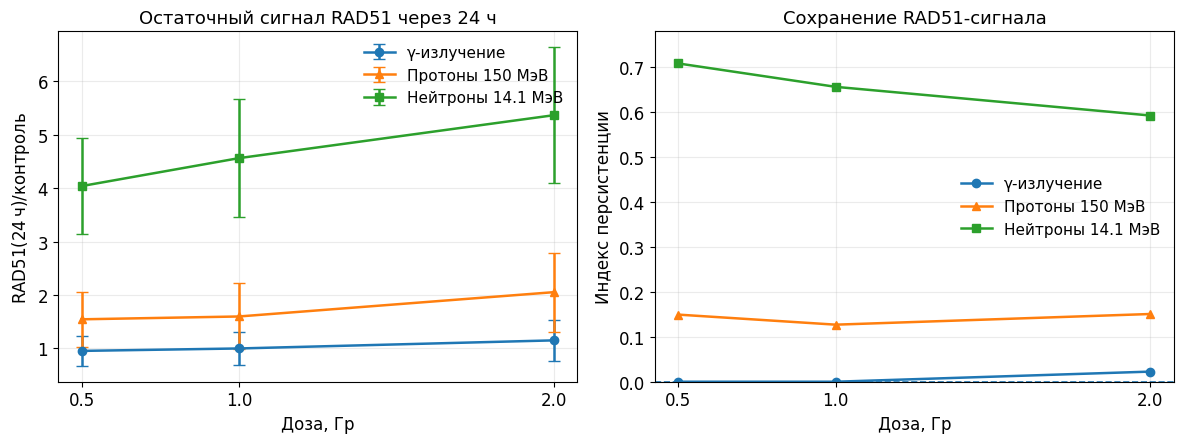

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# RAD51 data
# =========================================================
t = np.array([0.5, 2.0, 4.0, 6.0, 24.0], dtype=float)

ctrl_mean = np.array([1.23, 1.42, 1.11, 1.35, 1.32], dtype=float)
ctrl_se   = np.array([0.27, 0.31, 0.19, 0.22, 0.25], dtype=float)

RAD51 = {
    "γ-излучение": {
        0.5: {"mean": np.array([1.46, 2.50, 4.78, 5.64, 1.26]),
              "se":   np.array([0.29, 0.45, 0.54, 0.74, 0.28])},
        1.0: {"mean": np.array([1.54, 3.70, 6.73, 7.65, 1.32]),
              "se":   np.array([0.38, 0.58, 0.67, 0.58, 0.33])},
        2.0: {"mean": np.array([1.66, 4.01, 8.66, 10.23, 1.52]),
              "se":   np.array([0.46, 0.60, 0.96, 1.17, 0.41])},
    },

    "Протоны 150 МэВ": {
        0.5: {"mean": np.array([1.31, 3.50, 5.28, 6.17, 2.04]),
              "se":   np.array([0.39, 0.52, 0.83, 0.71, 0.55])},
        1.0: {"mean": np.array([1.43, 3.89, 6.99, 7.57, 2.11]),
              "se":   np.array([0.33, 0.77, 1.02, 0.91, 0.71])},
        2.0: {"mean": np.array([1.51, 4.23, 8.97, 10.57, 2.71]),
              "se":   np.array([0.42, 0.89, 1.26, 0.99, 0.83])},
    },

    "Нейтроны 14.1 МэВ": {
        0.5: {"mean": np.array([1.32, 2.95, 6.12, 7.01, 5.33]),
              "se":   np.array([0.44, 0.59, 0.87, 0.93, 0.64])},
        1.0: {"mean": np.array([1.89, 4.71, 7.56, 8.51, 6.02]),
              "se":   np.array([0.63, 0.87, 1.02, 1.36, 0.92])},
        2.0: {"mean": np.array([2.13, 5.37, 9.33, 11.07, 7.08]),
              "se":   np.array([0.57, 1.13, 1.54, 1.33, 1.01])},
    },
}

# =========================================================
# Helpers
# =========================================================
def ratio_with_se(a, sa, b, sb):
    """
    Ratio a/b with propagated SE.
    """
    ratio = a / b
    rel2 = (sa / a) ** 2 + (sb / b) ** 2
    se = ratio * np.sqrt(rel2)
    return ratio, se


def delta_with_se(a, sa, b, sb):
    """
    Difference a-b with propagated SE.
    """
    return a - b, np.sqrt(sa**2 + sb**2)

# =========================================================
# Build summary table — исправленная версия
# =========================================================
rows = []

peak_mask = np.isin(t, [2.0, 4.0, 6.0])

for radiation, dose_dict in RAD51.items():
    for dose, vals in dose_dict.items():
        mean = vals["mean"]
        se = vals["se"]

        delta, delta_se = delta_with_se(mean, se, ctrl_mean, ctrl_se)
        fc, fc_se = ratio_with_se(mean, se, ctrl_mean, ctrl_se)

        # максимум прироста RAD51 относительно контроля в окне 2–6 ч
        peak_delta = np.max(delta[peak_mask])
        peak_time = t[peak_mask][np.argmax(delta[peak_mask])]

        # остаточный сигнал в 24 ч
        residual_24h_delta = delta[-1]
        residual_24h_fc = fc[-1]
        residual_24h_fc_se = fc_se[-1]

        # ВАЖНО:
        # если RAD51 в 24 ч ниже контроля, считаем остаточный прирост равным 0,
        # а не отрицательным
        residual_24h_delta_pos = max(residual_24h_delta, 0.0)

        persistence_index = (
            residual_24h_delta_pos / peak_delta
            if peak_delta > 0 else np.nan
        )

        rows.append({
            "radiation": radiation,
            "dose_Gy": dose,
            "peak_time_h": peak_time,
            "peak_delta": peak_delta,
            "residual_24h_delta": residual_24h_delta,
            "residual_24h_delta_pos": residual_24h_delta_pos,
            "RAD51_24h_FC": residual_24h_fc,
            "RAD51_24h_FC_se": residual_24h_fc_se,
            "persistence_index": persistence_index,
        })

df_rad51_summary = pd.DataFrame(rows)

rad_order = {
    "γ-излучение": 0,
    "Протоны 150 МэВ": 1,
    "Нейтроны 14.1 МэВ": 2,
}
df_rad51_summary["_order"] = df_rad51_summary["radiation"].map(rad_order)
df_rad51_summary = (
    df_rad51_summary
    .sort_values(["_order", "dose_Gy"])
    .drop(columns="_order")
    .reset_index(drop=True)
)

display(df_rad51_summary)
# =========================================================
# Plot — исправленная версия
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

markers = {
    "γ-излучение": "o",
    "Протоны 150 МэВ": "^",
    "Нейтроны 14.1 МэВ": "s",
}

for radiation in ["γ-излучение", "Протоны 150 МэВ", "Нейтроны 14.1 МэВ"]:
    sub = df_rad51_summary[
        df_rad51_summary["radiation"] == radiation
    ].sort_values("dose_Gy")

    # RAD51 24 ч / контроль
    axes[0].errorbar(
        sub["dose_Gy"],
        sub["RAD51_24h_FC"],
        yerr=sub["RAD51_24h_FC_se"],
        marker=markers[radiation],
        capsize=4,
        linewidth=1.8,
        label=radiation,
    )

    # индекс персистенции, уже без отрицательных значений
    axes[1].plot(
        sub["dose_Gy"],
        sub["persistence_index"],
        marker=markers[radiation],
        linewidth=1.8,
        label=radiation,
    )


axes[0].set_xlabel("Доза, Гр")
axes[0].set_ylabel(r"RAD51$(24\,\mathrm{ч})$/контроль")
axes[0].set_title("Остаточный сигнал RAD51 через 24 ч")

axes[1].axhline(0.0, linestyle="--", linewidth=1.2)

axes[1].set_xlabel("Доза, Гр")
axes[1].set_ylabel("Индекс персистенции")
axes[1].set_title("Сохранение RAD51-сигнала")
axes[1].set_ylim(0, 0.78)

for ax in axes:
    ax.set_xticks([0.5, 1.0, 2.0])
    ax.legend()

plt.tight_layout()
plt.savefig("rad51_24h_persistence.png", dpi=300, bbox_inches="tight")
plt.show()

=== Таблица для проверки RAD51 ===


,radiation,dose_Gy,alpha,pi,RAD51_24h_FC,slow_pool,Du0_fraction,Du0_abs,Dc0_fraction
0,γ-излучение,0.5,0.231623,0.024713,0.954545,0.768377,0.018989,0.009494,0.749388
1,γ-излучение,1.0,0.190034,0.045250,1.000000,0.809966,0.036651,0.036651,0.773315
2,γ-излучение,2.0,0.385335,0.063004,1.151515,0.614665,0.038726,0.077453,0.575939
3,Протоны 150 МэВ,0.5,0.687007,0.329032,1.545455,0.312993,0.102985,0.051492,0.210008
4,Протоны 150 МэВ,1.0,0.319425,0.091171,1.598485,0.680575,0.062049,0.062049,0.618526
5,Протоны 150 МэВ,2.0,0.552002,0.127730,2.053030,0.447998,0.057223,0.114446,0.390775
6,Нейтроны 14.1 МэВ,0.5,0.588580,0.288091,4.037879,0.411420,0.118526,0.059263,0.292894
7,Нейтроны 14.1 МэВ,1.0,0.710574,0.322786,4.560606,0.289426,0.093423,0.093423,0.196003
8,Нейтроны 14.1 МэВ,2.0,0.804320,0.448824,5.363636,0.195680,0.087826,0.175652,0.107854



=== Корреляции с RAD51(24 ч)/контроль ===


,x,y,n,spearman_rho,spearman_p,linear_slope,linear_intercept,linear_r,linear_R2,linear_p
0,Du0_fraction,RAD51_24h_FC,9,0.716667,0.029818,35.407165,0.048919,0.705583,0.497847,0.033697
1,Du0_abs,RAD51_24h_FC,9,0.800000,0.009628,25.270710,0.564781,0.718804,0.516679,0.029105
2,pi,RAD51_24h_FC,9,0.833333,0.005266,9.369958,0.661755,0.851581,0.725191,0.003576
3,alpha,RAD51_24h_FC,9,0.850000,0.003705,6.148400,-0.579048,0.803751,0.646016,0.009046
4,Dc0_fraction,RAD51_24h_FC,9,-0.850000,0.003705,-5.483139,4.858890,-0.808216,0.653213,0.008385



--- Главное для текста ---
D_u0/D vs RAD51(24h)/control: Spearman rho = 0.717, p = 0.0298, R^2 = 0.498
D_u0_abs vs RAD51(24h)/control: Spearman rho = 0.800, p = 0.0096, R^2 = 0.517


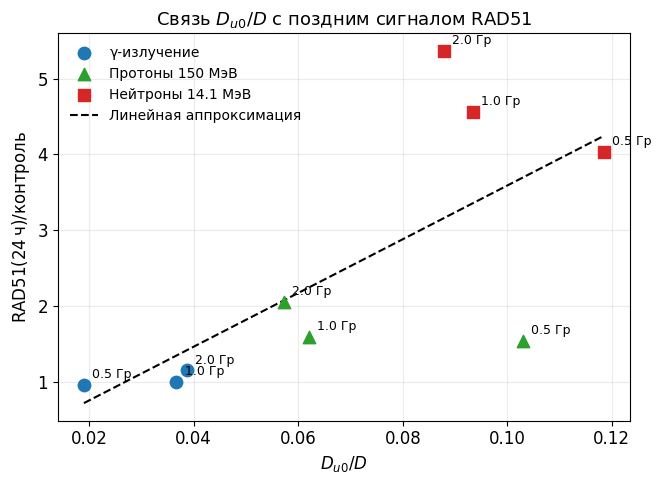

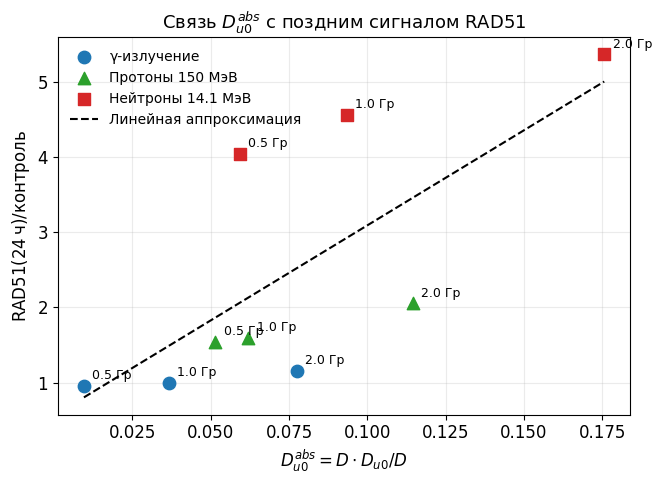

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress
from IPython.display import display

# =========================================================
# Данные для внешней проверки RAD51
# Используем только дозы 0.5, 1.0, 2.0 Гр,
# потому что RAD51 есть именно для этих доз.
# =========================================================

rows = [
    # radiation, dose, alpha, pi, RAD51_24h/control

    # gamma, отдельные подгонки расширенной модели
    ("γ-излучение", 0.5, 0.231623, 0.024713, 0.954545),
    ("γ-излучение", 1.0, 0.190034, 0.045250, 1.000000),
    ("γ-излучение", 2.0, 0.385335, 0.063004, 1.151515),

    # protons 150 MeV, отдельные подгонки расширенной модели
    ("Протоны 150 МэВ", 0.5, 0.687007, 0.329032, 1.545455),
    ("Протоны 150 МэВ", 1.0, 0.319425, 0.091171, 1.598485),
    ("Протоны 150 МэВ", 2.0, 0.552002, 0.127730, 2.053030),

    # neutrons 14.1 MeV, отдельные подгонки расширенной модели
    ("Нейтроны 14.1 МэВ", 0.5, 0.588580, 0.288091, 4.037879),
    ("Нейтроны 14.1 МэВ", 1.0, 0.710574, 0.322786, 4.560606),
    ("Нейтроны 14.1 МэВ", 2.0, 0.804320, 0.448824, 5.363636),
]

df = pd.DataFrame(
    rows,
    columns=["radiation", "dose_Gy", "alpha", "pi", "RAD51_24h_FC"]
)

# =========================================================
# Модельные величины
# =========================================================

df["slow_pool"] = 1.0 - df["alpha"]
df["Du0_fraction"] = df["slow_pool"] * df["pi"]          # D_u0 / D
df["Du0_abs"] = df["dose_Gy"] * df["Du0_fraction"]       # D_u0 absolute, в условных дозовых единицах
df["Dc0_fraction"] = df["slow_pool"] * (1.0 - df["pi"])

print("=== Таблица для проверки RAD51 ===")
display(df)

# =========================================================
# Функция для корреляции и линейной регрессии
# =========================================================

def analyze_relation(xcol, ycol="RAD51_24h_FC"):
    x = df[xcol].values
    y = df[ycol].values

    rho, p_spearman = spearmanr(x, y)
    lr = linregress(x, y)

    result = {
        "x": xcol,
        "y": ycol,
        "n": len(df),
        "spearman_rho": rho,
        "spearman_p": p_spearman,
        "linear_slope": lr.slope,
        "linear_intercept": lr.intercept,
        "linear_r": lr.rvalue,
        "linear_R2": lr.rvalue**2,
        "linear_p": lr.pvalue,
    }

    return result

results = pd.DataFrame([
    analyze_relation("Du0_fraction"),
    analyze_relation("Du0_abs"),
    analyze_relation("pi"),
    analyze_relation("alpha"),
    analyze_relation("Dc0_fraction"),
])

print("\n=== Корреляции с RAD51(24 ч)/контроль ===")
display(results)

# =========================================================
# Печать главных результатов
# =========================================================

main_du_frac = analyze_relation("Du0_fraction")
main_du_abs = analyze_relation("Du0_abs")

print("\n--- Главное для текста ---")
print(
    "D_u0/D vs RAD51(24h)/control: "
    f"Spearman rho = {main_du_frac['spearman_rho']:.3f}, "
    f"p = {main_du_frac['spearman_p']:.4f}, "
    f"R^2 = {main_du_frac['linear_R2']:.3f}"
)

print(
    "D_u0_abs vs RAD51(24h)/control: "
    f"Spearman rho = {main_du_abs['spearman_rho']:.3f}, "
    f"p = {main_du_abs['spearman_p']:.4f}, "
    f"R^2 = {main_du_abs['linear_R2']:.3f}"
)

# =========================================================
# График 1: RAD51 vs D_u0/D
# =========================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

color_map = {
    "γ-излучение": "tab:blue",
    "Протоны 150 МэВ": "tab:green",
    "Нейтроны 14.1 МэВ": "tab:red",
}

marker_map = {
    "γ-излучение": "o",
    "Протоны 150 МэВ": "^",
    "Нейтроны 14.1 МэВ": "s",
}

fig, ax = plt.subplots(figsize=(6.8, 5.0))

for radiation in ["γ-излучение", "Протоны 150 МэВ", "Нейтроны 14.1 МэВ"]:
    sub = df[df["radiation"] == radiation]

    ax.scatter(
        sub["Du0_fraction"],
        sub["RAD51_24h_FC"],
        s=80,
        marker=marker_map[radiation],
        color=color_map[radiation],
        label=radiation,
        zorder=3
    )

    # подписи доз рядом с точками
    for _, row in sub.iterrows():
        ax.annotate(
            f'{row["dose_Gy"]} Гр',
            (row["Du0_fraction"], row["RAD51_24h_FC"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=9
        )

# Линейная регрессия по всем точкам
x = df["Du0_fraction"].values
y = df["RAD51_24h_FC"].values
lr = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = lr.intercept + lr.slope * x_line

ax.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Линейная аппроксимация"
)

rho, p_s = spearmanr(x, y)

ax.set_xlabel(r"$D_{u0}/D$")
ax.set_ylabel(r"RAD51$(24\,\mathrm{ч})$/контроль")
ax.set_title(
    r"Связь $D_{u0}/D$ с поздним сигналом RAD51"

)

ax.legend()
plt.tight_layout()
plt.savefig("rad51_vs_du0_fraction.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# График 2: RAD51 vs абсолютное D_u0
# =========================================================

fig, ax = plt.subplots(figsize=(6.8, 5.0))

for radiation in ["γ-излучение", "Протоны 150 МэВ", "Нейтроны 14.1 МэВ"]:
    sub = df[df["radiation"] == radiation]

    ax.scatter(
        sub["Du0_abs"],
        sub["RAD51_24h_FC"],
        s=80,
        marker=marker_map[radiation],
        color=color_map[radiation],
        label=radiation,
        zorder=3
    )

    for _, row in sub.iterrows():
        ax.annotate(
            f'{row["dose_Gy"]} Гр',
            (row["Du0_abs"], row["RAD51_24h_FC"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=9
        )

x = df["Du0_abs"].values
y = df["RAD51_24h_FC"].values
lr = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = lr.intercept + lr.slope * x_line

ax.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Линейная аппроксимация"
)

rho, p_s = spearmanr(x, y)

ax.set_xlabel(r"$D_{u0}^{abs}=D\cdot D_{u0}/D$")
ax.set_ylabel(r"RAD51$(24\,\mathrm{ч})$/контроль")
ax.set_title(
    r"Связь $D_{u0}^{abs}$ с поздним сигналом RAD51"

)

ax.legend()
plt.tight_layout()
plt.savefig("rad51_vs_du0_abs.png", dpi=300, bbox_inches="tight")
plt.show()